# Dataset Description

[Data is taken from here](https://www.kaggle.com/datasets/stealthtechnologies/employee-attrition-dataset)

FEATURES:

Employee ID: A unique identifier assigned to each employee.

Age: The age of the employee, ranging from 18 to 60 years.

Gender: The gender of the employee

Years at Company: The number of years the employee has been working at the company.

Monthly Income: The monthly salary of the employee, in dollars.

Job Role: The department or role the employee works in, encoded into categories such as Finance, Healthcare, Technology, Education, and Media.

Work-Life Balance: The employee's perceived balance between work and personal life, (Poor, Below Average, Good, Excellent)

Job Satisfaction: The employee's satisfaction with their job: (Very Low, Low, Medium, High)

Performance Rating: The employee's performance rating: (Low, Below Average, Average, High)

Number of Promotions: The total number of promotions the employee has received.

Distance from Home: The distance between the employee's home and workplace, in miles.

Education Level: The highest education level attained by the employee: (High School, Associate Degree, Bachelor’s Degree, Master’s Degree, PhD)

Marital Status: The marital status of the employee: (Divorced, Married, Single)

Job Level: The job level of the employee: (Entry, Mid, Senior)

Company Size: The size of the company the employee works for: (Small,Medium,Large)

Company Tenure: The total number of years the employee has been working in the industry.

Remote Work: Whether the employee works remotely: (Yes or No)

Leadership Opportunities: Whether the employee has leadership opportunities: (Yes or No)

Innovation Opportunities: Whether the employee has opportunities for innovation: (Yes or No)

Company Reputation: The employee's perception of the company's reputation: (Very Poor, Poor,Good, Excellent)

Employee Recognition: The level of recognition the employee receives:(Very Low, Low, Medium, High)

Attrition: Whether the employee has left the company, encoded as 0 (stayed) and 1 (Left).

From Kaggle Dataset description:

> The dataset comprises 74,498 samples, split into training and testing sets to facilitate model development and evaluation. Each record includes a unique Employee ID and features that influence employee attrition. The goal is to understand the factors contributing to attrition and develop predictive models to identify at-risk employees.




# Data Downloading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
train_df = pd.read_csv('train_attrition.csv')
train_df.shape

(59598, 24)

In [3]:
train_df.sample(7)

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
16948,1101,46,Male,22,Healthcare,9334,Good,Very High,Average,0,...,0,Entry,Small,58,Yes,No,No,Excellent,Medium,Left
30914,22762,33,Male,23,Media,6226,Good,High,Below Average,0,...,2,Mid,Medium,68,No,No,Yes,Fair,Medium,Stayed
34429,59434,41,Female,20,Finance,6546,Poor,High,Average,0,...,0,Senior,Medium,87,No,No,No,Poor,Low,Left
46907,16892,20,Female,9,Media,6004,Excellent,High,Below Average,0,...,0,Entry,Small,22,No,No,No,Fair,High,Left
46758,62817,59,Male,49,Media,7218,Good,High,Average,0,...,1,Senior,Small,55,No,No,No,Good,High,Stayed
44370,18372,47,Female,11,Healthcare,9048,Fair,High,Average,0,...,0,Entry,Small,80,No,No,Yes,Excellent,Low,Left
41280,5273,19,Female,9,Education,5247,Fair,Medium,Average,0,...,0,Mid,Small,11,Yes,No,Yes,Good,Medium,Stayed


In [4]:
train_df.info() # Here one can clearly see that there is no Null instances for all the feautures

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

Although the type of 'Number of Promotions' is int64, it is a discrete RV and hence we will change its type to object to properly deal with it later

In [5]:
train_df['Number of Promotions'] = train_df['Number of Promotions'].astype('object')

Even though feature engineering part will take place after data visualization, we will now drop column 'Number of Dependents' since there is no information about this feature in the dataset overview and column 'Company Tenure' since there almost 45000 rows which have 'Company Tenure' > 'Age' while the definition of this feature is 'The total number of years the employee has been working in the industry' and thus this feature is not properly defined.

In [6]:
train_df = train_df.drop(columns=['Number of Dependents', 'Company Tenure', 'Employee ID'])

In [7]:
# Looking on whether there are any duplicates
train_df.duplicated().sum() # No duplicates

np.int64(0)

Well, no actual class imbalance

The *test dataset* is needed just to test the predictive power of future models hence we will not touch it until the end

In [8]:
# Selecting columns based on their dtype
obj_columns = list(train_df.select_dtypes(include='object').columns)
num_columns = list(train_df.select_dtypes(include=['float', 'int']).columns)
num_target_cols = num_columns + ['Attrition']

In [9]:
# Actually it would be better to decode target variable (Attrition) into 1/0 variable
train_df['Attrition'] = train_df['Attrition'].apply(lambda x: 1 if x == 'Left' else 0)

Left = 1, stayed = 0

In [10]:
# Also we should look at potential class imbalance
train_df.loc[train_df['Attrition'] == 0].shape[0], train_df.loc[train_df['Attrition'] == 1].shape[0]

(31260, 28338)

# Data Visualization

Firstly, we will deal with numerical columns  

In [ ]:
train_df.describe().round(2)

,Age,Years at Company,Monthly Income,Distance from Home,Attrition
count,59598.00,59598.00,59598.00,59598.00,59598.00
mean,38.57,15.75,7302.40,50.01,0.48
std,12.08,11.25,2151.46,28.47,0.50
min,18.00,1.00,1316.00,1.00,0.00
25%,28.00,7.00,5658.00,25.00,0.00
50%,39.00,13.00,7354.00,50.00,0.00
75%,49.00,23.00,8880.00,75.00,1.00
max,59.00,51.00,16149.00,99.00,1.00


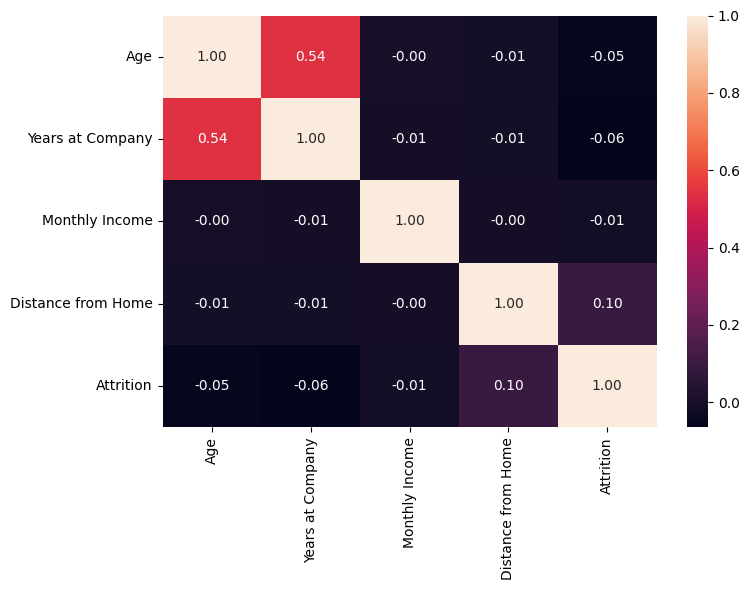

In [ ]:
# Look at correlation between features for further dimensionality reduction
plt.figure(figsize=(8, 6))
sns.heatmap(train_df.loc[:, num_target_cols].corr(), cmap=sns.color_palette('rocket', as_cmap=True), annot=True, fmt='.2f') # We will use 'rocket' palette
plt.tight_layout()
plt.savefig('Heatmap 1', dpi=800, bbox_inches='tight')
plt.show()

One can see that there is almost no highly correlated variables except for 'Age' and 'Years at Company' (though corr = 0.54 which is not extremly bad)

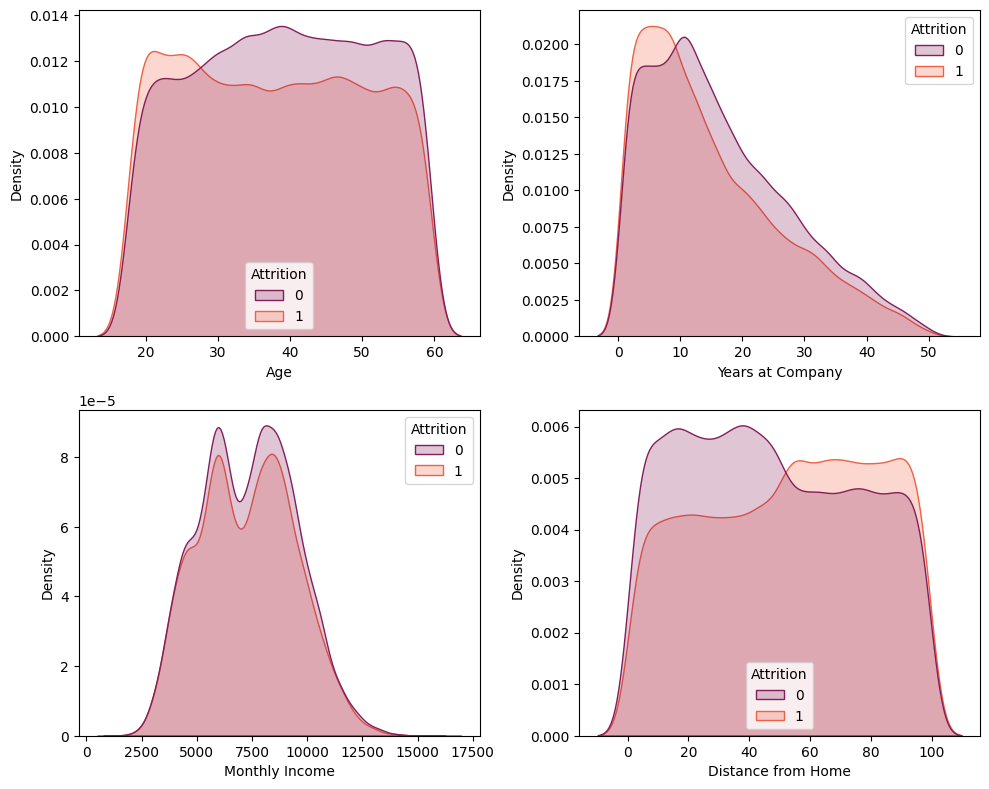

In [ ]:
# Will look at distributions of these variables w.r.t target variable
fig, ax = plt.subplots(2, 2, figsize=(10,8))
sns.kdeplot(data=train_df, x='Age', hue='Attrition', fill=True, palette = 'rocket', ax=ax[0,0])
sns.kdeplot(data=train_df, x='Years at Company', hue='Attrition', fill=True, palette = 'rocket', ax=ax[0,1])
sns.kdeplot(data=train_df, x='Monthly Income', hue='Attrition', fill=True, palette = 'rocket', ax=ax[1,0])
sns.kdeplot(data=train_df, x='Distance from Home', hue='Attrition', fill=True, palette = 'rocket', ax=ax[1,1])
plt.tight_layout()
plt.savefig('Distribution continuos vars', dpi=800, bbox_inches='tight')
plt.show()

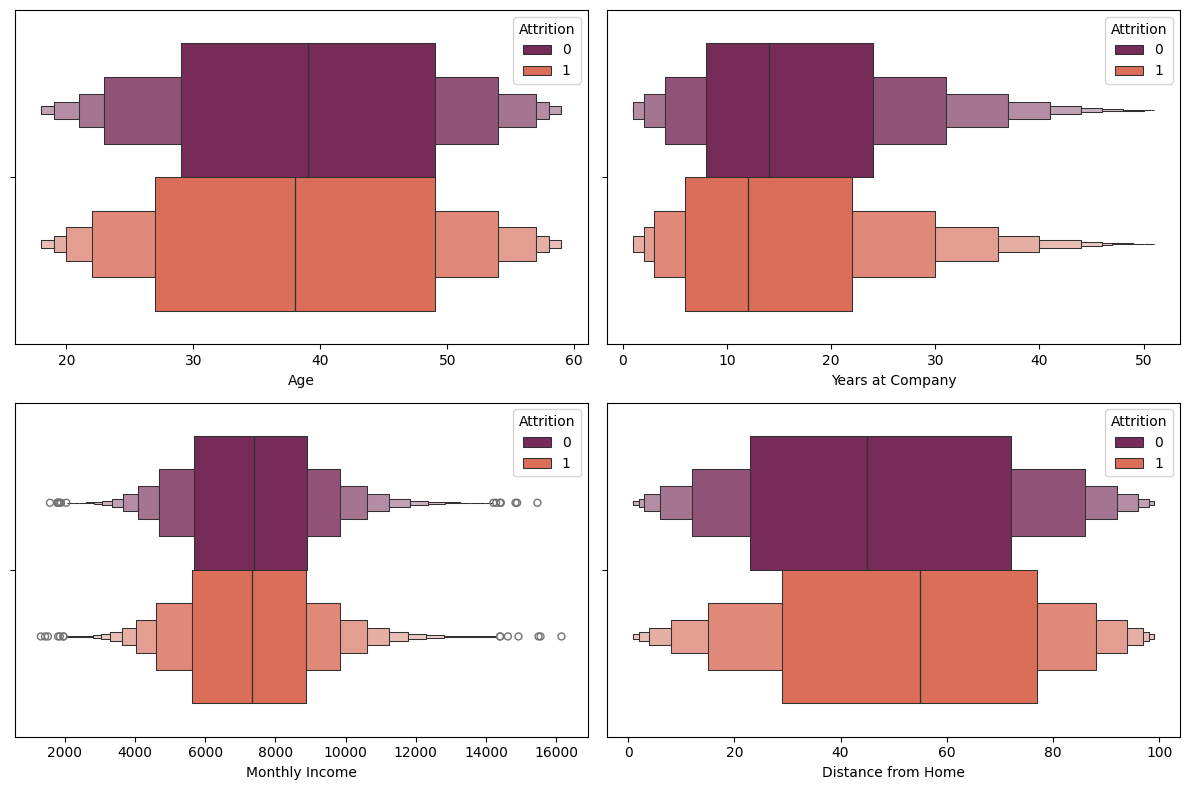

In [ ]:
# Checking for outliers
fig, ax = plt.subplots(2, 2, figsize=(12,8))
sns.boxenplot(data=train_df, x='Age', hue='Attrition', palette = 'rocket', ax=ax[0,0])
sns.boxenplot(data=train_df, x='Years at Company', hue='Attrition', palette = 'rocket', ax=ax[0,1])
sns.boxenplot(data=train_df, x='Monthly Income', hue='Attrition', palette = 'rocket', ax=ax[1,0])
sns.boxenplot(data=train_df, x='Distance from Home', hue='Attrition', palette = 'rocket', ax=ax[1,1])
plt.tight_layout()
plt.savefig('boxenplots', dpi=800, bbox_inches='tight')
plt.show()

Basically, there is no extreme outliers, but these for 'Monthly Income' (and possibly for 'Years at company') should be born in mind until the next section

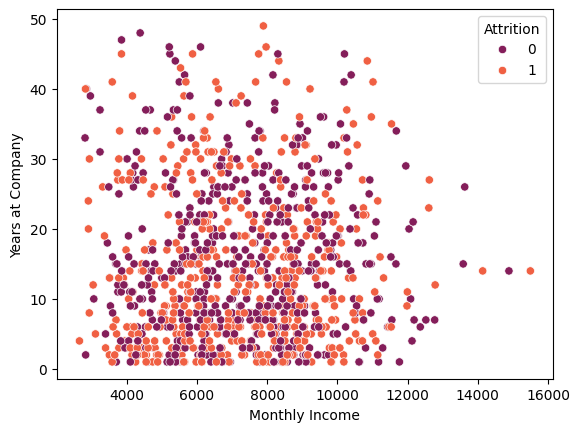

In [ ]:
# Lets look on some pairwise dependencies
sns.scatterplot(data=train_df.sample(1000), x = 'Monthly Income', y='Years at Company', hue='Attrition', palette='rocket')
plt.show()

Nothing really worth mentioning

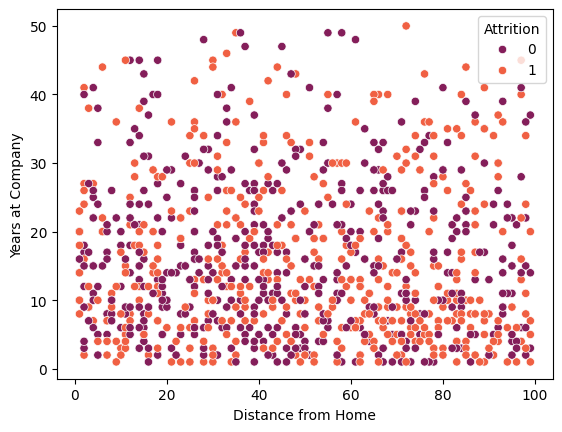

In [ ]:
sns.scatterplot(data=train_df.sample(1000), x = 'Distance from Home', y='Years at Company', hue='Attrition', palette='rocket')
plt.show()

Just some chaotic points

Now we switch to categorical features

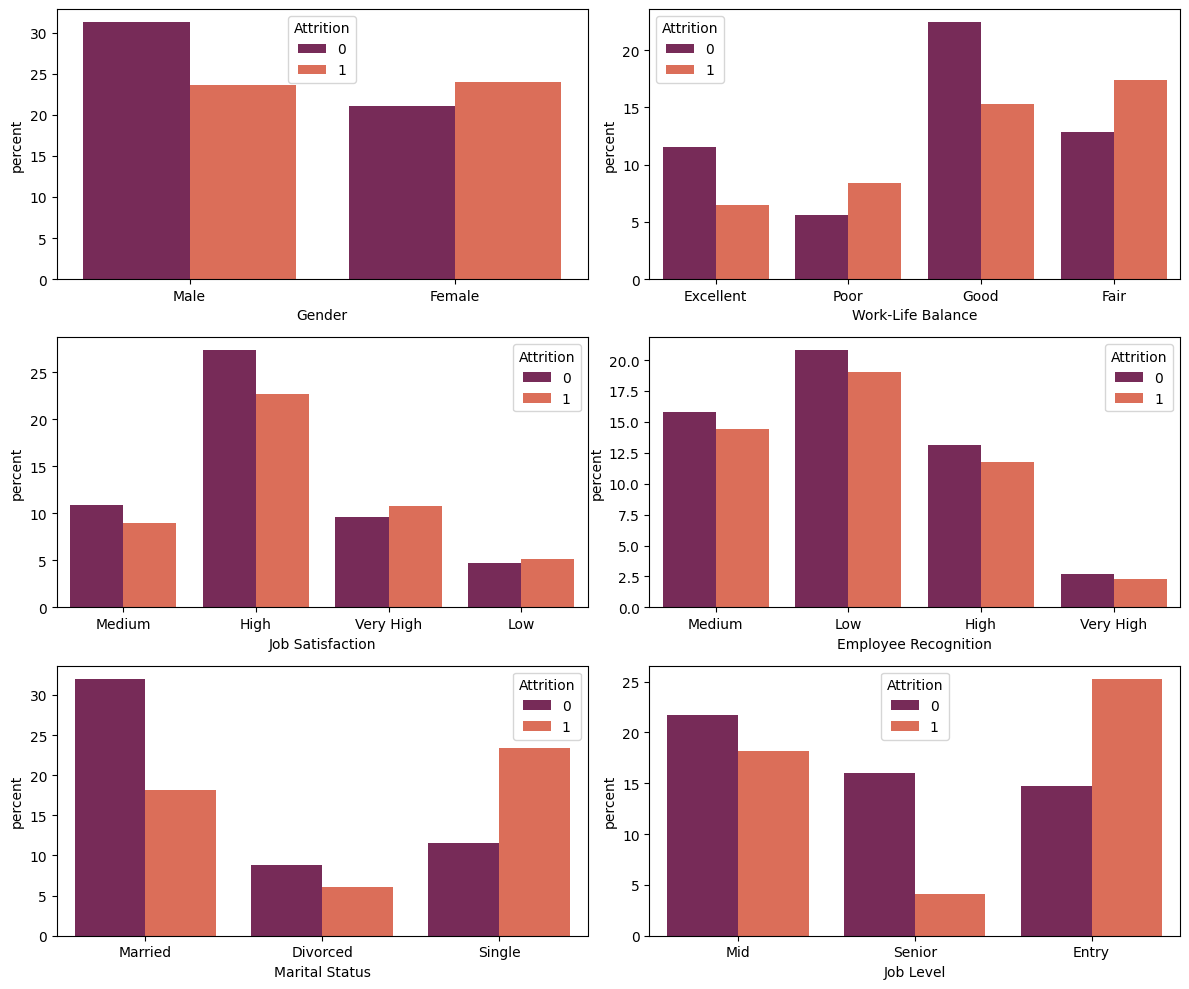

In [ ]:
# Firstly, lets choose 6 most important (subjectively of course) features and look at their countplots
# For example, lets take Gender, Worl-Life Balance, Job Satisfaction, Marital Status, Job Level, Employee Recognition
fig, ax = plt.subplots(3, 2, figsize=(12,10))
sns.countplot(data=train_df, x='Gender', hue='Attrition', palette = 'rocket', stat='percent', ax=ax[0,0])
sns.countplot(data=train_df, x='Work-Life Balance', hue='Attrition', palette = 'rocket', stat='percent', ax=ax[0,1])
sns.countplot(data=train_df, x='Job Satisfaction', hue='Attrition', palette = 'rocket', stat='percent', ax=ax[1,0])
sns.countplot(data=train_df, x='Employee Recognition', hue='Attrition', palette = 'rocket', stat='percent', ax=ax[1,1])
sns.countplot(data=train_df, x='Marital Status', hue='Attrition', palette = 'rocket', stat='percent', ax=ax[2,0])
sns.countplot(data=train_df, x='Job Level', hue='Attrition', palette = 'rocket', stat='percent', ax=ax[2,1])
plt.tight_layout()
plt.savefig('Barplots', dpi=800, bbox_inches='tight')
plt.show()

So one can see that there are already some features that can be good predictors for target variable, such as 'Marital Status' or 'Job Level'

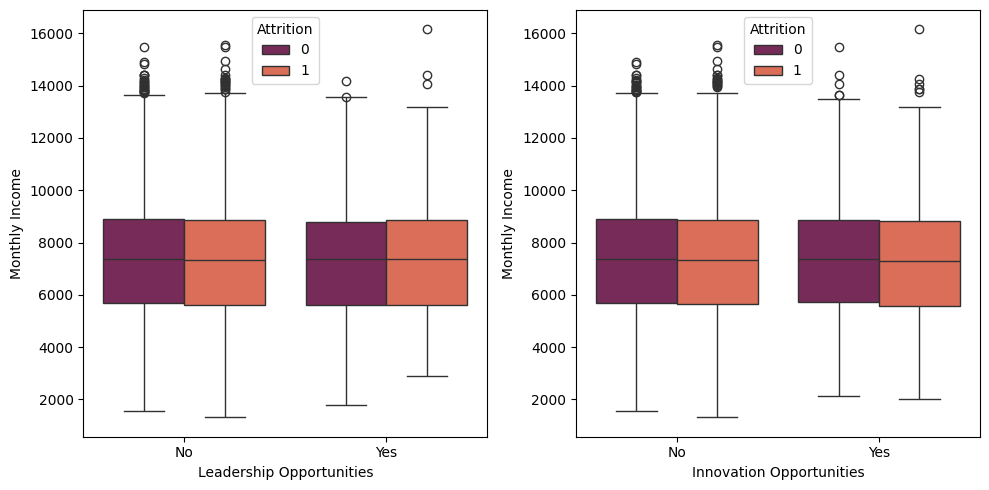

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
sns.boxplot(data=train_df, x='Leadership Opportunities', y='Monthly Income', hue='Attrition', palette='rocket', ax=ax[0])
sns.boxplot(data=train_df, x='Innovation Opportunities', y='Monthly Income', hue='Attrition', palette='rocket', ax=ax[1])
plt.tight_layout()
ax[0].legend(loc='upper center', title='Attrition')
ax[1].legend(loc='upper center', title='Attrition')
plt.show()

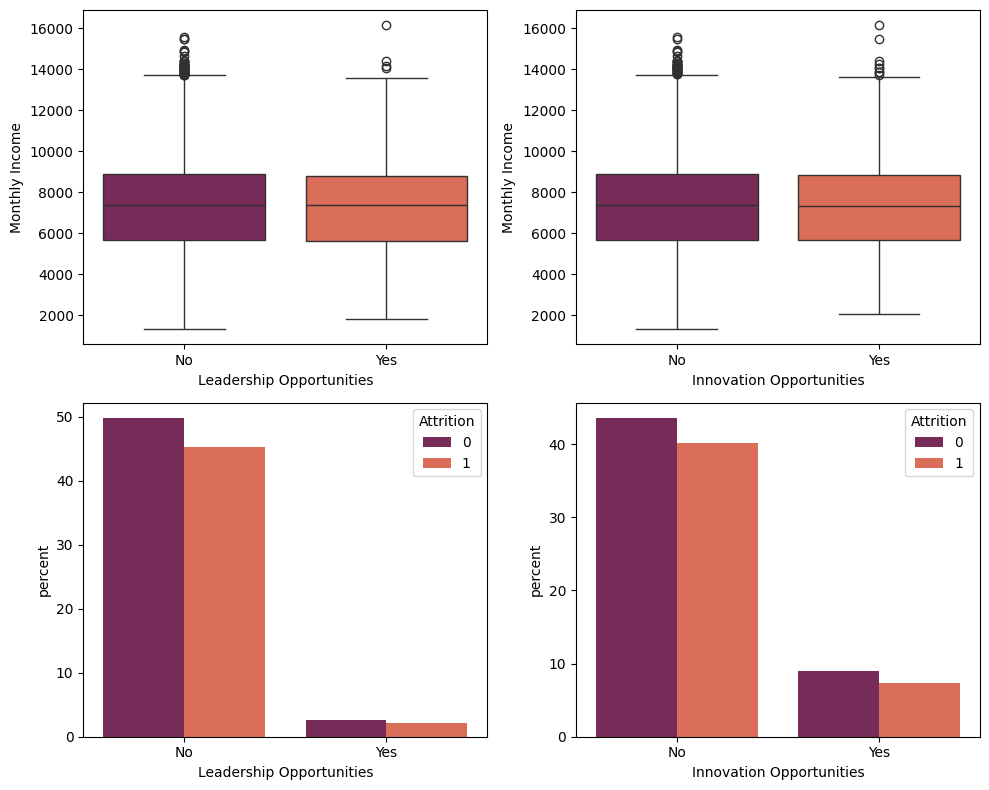

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10,8))
sns.boxplot(data=train_df, x='Leadership Opportunities', y='Monthly Income', palette='rocket', ax=ax[0, 0])
sns.boxplot(data=train_df, x='Innovation Opportunities', y='Monthly Income', palette='rocket', ax=ax[0, 1])
sns.countplot(data=train_df, x='Leadership Opportunities', hue='Attrition', palette='rocket', stat='percent', ax=ax[1,0])
sns.countplot(data=train_df, x='Innovation Opportunities', hue='Attrition', palette='rocket', stat='percent', ax=ax[1,1])
plt.tight_layout()
plt.savefig('Opportunities', dpi=800, bbox_inches='tight')
plt.show()

In [ ]:
pd.crosstab(train_df['Leadership Opportunities'], train_df['Job Level'])

Job Level,Entry,Mid,Senior
Leadership Opportunities,,,
No,22675,22612,11393
Yes,1192,1141,585


In [ ]:
pd.crosstab(train_df['Innovation Opportunities'], train_df['Job Level'])

Job Level,Entry,Mid,Senior
Innovation Opportunities,,,
No,20038,19915,9942
Yes,3829,3838,2036


Also we may look at 'Number of Promotions' separately as it has at least 5 unique values

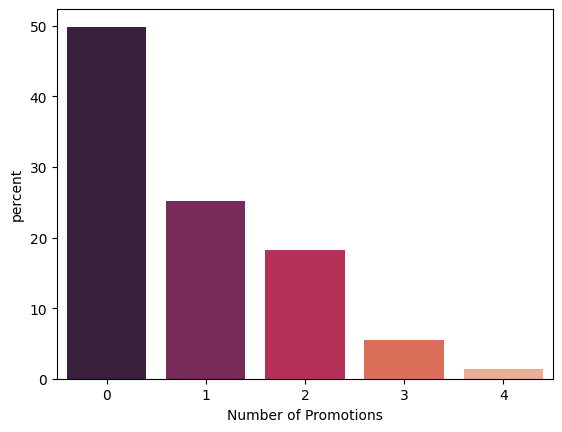

In [ ]:
sns.countplot(data=train_df, x='Number of Promotions', palette='rocket', stat='percent')
plt.show()

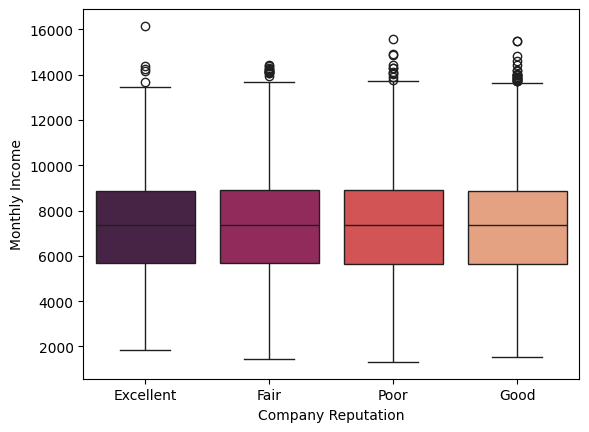

In [ ]:
# Finally, we will look at montlhy incomes w.r.t company reputation
sns.boxplot(data=train_df, x='Company Reputation', y='Monthly Income', palette='rocket')
plt.show()

**Some hypothesis testings**

In [ ]:
# Firstly, lets check the hypothesis that mean monthly income for people with leadership opportunities and without them are equal
from scipy import stats

leaders = train_df.loc[train_df['Leadership Opportunities'] == 'Yes']['Monthly Income'].to_list()
not_leaders = train_df.loc[train_df['Leadership Opportunities'] == 'No']['Monthly Income'].to_list()
t_statistic, p_value = stats.ttest_ind(leaders, not_leaders, equal_var=False)
print(f'T-statistic: {t_statistic}')
print(f'P-value: {p_value}')

T-statistic: -1.1086264242851374
P-value: 0.2676741347110189


For this test H0 states that mean values between two groups are equal and we get that p-value is quite high, so we cannot reject the null and thus can say that average monthly income for people with leadership opportunities is the same as for people without it

In [ ]:
# Doing the same for innovation opportunities
innovators = train_df.loc[train_df['Innovation Opportunities'] == 'Yes']['Monthly Income'].to_list()
not_innovators = train_df.loc[train_df['Innovation Opportunities'] == 'No']['Monthly Income'].to_list()
t_statistic, p_value = stats.ttest_ind(innovators, not_innovators, equal_var=False)
print(f'T-statistic: {t_statistic}')
print(f'P-value: {p_value}')

T-statistic: -0.6508055866247442
P-value: 0.5151828445757718


We get the same conclusion

Also we may test a hypothesis (based on real life) that proportion of people with remote work who quitted their job is smaller than the proportion of people without remote work who have also left

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

remote_quitted = train_df.loc[(train_df['Attrition'] == 1) & (train_df['Remote Work'] == 'Yes')]
remote_stayed = train_df.loc[(train_df['Attrition'] == 0) & (train_df['Remote Work'] == 'Yes')]
remote = train_df.loc[train_df['Remote Work'] == 'Yes']
count = np.array([remote_quitted.shape[0], remote_stayed.shape[0]])
nobs = np.array([remote.shape[0], remote.shape[0]])
z_statistic, p_value = proportions_ztest(count, nobs, alternative='smaller')
print(f'Z-statistic: {z_statistic}')
print(f'P-value: {p_value}')

Z-statistic: -75.78043749728928
P-value: 0.0


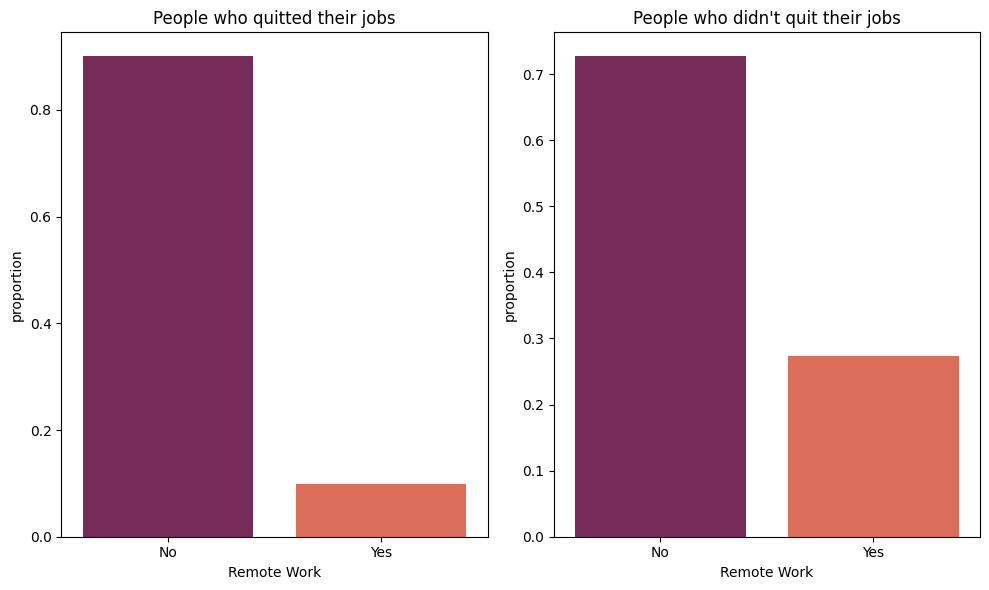

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,6))

sns.countplot(data=train_df.loc[(train_df['Attrition'] == 1)], x='Remote Work', palette='rocket', stat='proportion', ax=axes[0])
axes[0].set_title('People who quitted their jobs')

sns.countplot(data=train_df.loc[(train_df['Attrition'] == 0)], x='Remote Work', palette='rocket', stat='proportion', ax=axes[1])
axes[1].set_title('People who didn't quit their jobs')

plt.tight_layout()
plt.savefig('Remote Work', dpi=800, bbox_inches='tight')
plt.show()

So we should reject the null in favor of alternative that proportion of people that quitted their remote jobs is less than the proportion of people without remote job and thus conclude that our hypothesis was true

# Data Preprocessing & Feature Engineering

We will start with encoding discrete features and we will not proceed through scaling continuous variables since this will cause data leakage during cross-validation. Instead, different techniques such as standard scaler and etc. will appear directly in pipelines

What's more important, we will leave the initial dataframe without any kind of encodings for the future train of CatBoost as it has its own techniques of encoding

In [11]:
train_df_catboost = train_df.loc[:,:]

For our dataset standard ordinal for ordinal columns + OHE for the rest encoders will be used

In [12]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Ordinal Encodings
# Preparation
ordinal_categories = [
    ['Poor', 'Fair', 'Good', 'Excellent'], # Work-Life Balance
    ['Low', 'Medium', 'High', 'Very High'],   # Job Satisfaction
    ['Low', 'Below Average', 'Average', 'High'], # Performance Rating
    ['High School', 'Associate Degree', 'Bachelor’s Degree', 'Master’s Degree', 'PhD'],  # Education Level
    ['Entry', 'Mid', 'Senior'], # Job Level
    ['Small', 'Medium', 'Large'], # Company Size
    ['Poor', 'Fair', 'Good', 'Excellent'], # Company Reputation
    ['Low', 'Medium', 'High', 'Very High'], # Employee Recognition
    [0, 1, 2, 3, 4] # Number of Promotions
]

# Actual encoding
ordinal_columns = ['Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Education Level', 'Job Level', 'Company Size', 'Company Reputation', 'Employee Recognition', 'Number of Promotions']
ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)
ordinal_encoded = ordinal_encoder.fit_transform(train_df[ordinal_columns])
feature_names = ordinal_encoder.get_feature_names_out(ordinal_columns)
ordinal_encoded_df = pd.DataFrame(columns=feature_names, data=ordinal_encoded)
ordinal_encoded_df.head()

,Work-Life Balance,Job Satisfaction,Performance Rating,Education Level,Job Level,Company Size,Company Reputation,Employee Recognition,Number of Promotions
0,3.0,1.0,2.0,1.0,1.0,1.0,3.0,1.0,2.0
1,0.0,2.0,0.0,3.0,1.0,1.0,1.0,0.0,3.0
2,2.0,2.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0
3,2.0,2.0,3.0,0.0,1.0,0.0,2.0,1.0,1.0
4,1.0,3.0,2.0,0.0,2.0,1.0,1.0,1.0,0.0


In [13]:
# Now move to OHE encoding
ohe_columns = list(set(obj_columns[:-1]) - set(ordinal_columns))
ohe = OneHotEncoder(sparse_output=False, drop='first', dtype='bool')
ohe_fitted = ohe.fit_transform(train_df[ohe_columns])
feature_names_ohe = ohe.get_feature_names_out(ohe_columns)
ohe_encoded_df = pd.DataFrame(columns=feature_names_ohe, data=ohe_fitted)
ohe_encoded_df.head()

,Leadership Opportunities_Yes,Marital Status_Married,Marital Status_Single,Overtime_Yes,Gender_Male,Remote Work_Yes,Job Role_Finance,Job Role_Healthcare,Job Role_Media,Job Role_Technology,Innovation Opportunities_Yes
0,False,True,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,False
2,False,True,False,False,False,False,False,True,False,False,False
3,False,False,True,False,False,True,False,False,False,False,False
4,False,False,False,True,True,False,False,False,False,False,False


In [14]:
train_df = train_df.drop(columns=ordinal_columns)
train_df = train_df.drop(columns=ohe_columns)
train_df.head()

,Age,Years at Company,Monthly Income,Distance from Home,Attrition
0,31,19,5390,22,0
1,59,4,5534,21,0
2,24,10,8159,11,0
3,36,7,3989,27,0
4,56,41,4821,71,0


In [15]:
# No we have to bring it all together
train_df = pd.concat([train_df, ordinal_encoded_df, ohe_encoded_df], axis=1)
train_df.head()

,Age,Years at Company,Monthly Income,Distance from Home,Attrition,Work-Life Balance,Job Satisfaction,Performance Rating,Education Level,Job Level,...,Marital Status_Married,Marital Status_Single,Overtime_Yes,Gender_Male,Remote Work_Yes,Job Role_Finance,Job Role_Healthcare,Job Role_Media,Job Role_Technology,Innovation Opportunities_Yes
0,31,19,5390,22,0,3.0,1.0,2.0,1.0,1.0,...,True,False,False,True,False,False,False,False,False,False
1,59,4,5534,21,0,0.0,2.0,0.0,3.0,1.0,...,False,False,False,False,False,False,False,True,False,False
2,24,10,8159,11,0,2.0,2.0,0.0,2.0,1.0,...,True,False,False,False,False,False,True,False,False,False
3,36,7,3989,27,0,2.0,2.0,3.0,0.0,1.0,...,False,True,False,False,True,False,False,False,False,False
4,56,41,4821,71,0,1.0,3.0,2.0,0.0,2.0,...,False,False,True,True,False,False,False,False,False,False


In [16]:
# Lets check the new columns we have
print(train_df.columns)
print(f'Number of new columns {train_df.shape[1] - train_df_catboost.shape[1]}')

Index(['Age', 'Years at Company', 'Monthly Income', 'Distance from Home',
       'Attrition', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Education Level', 'Job Level', 'Company Size',
       'Company Reputation', 'Employee Recognition', 'Number of Promotions',
       'Leadership Opportunities_Yes', 'Marital Status_Married',
       'Marital Status_Single', 'Overtime_Yes', 'Gender_Male',
       'Remote Work_Yes', 'Job Role_Finance', 'Job Role_Healthcare',
       'Job Role_Media', 'Job Role_Technology',
       'Innovation Opportunities_Yes'],
      dtype='object')
Number of new columns 4


That looks fine

Now we have two things to complete before moving to the actual model implementation:
1) Work with outliers for monthly income;
2) Create new features based on what we have right now.


For the first thing, lets look solely on this outliers (basically, what we have to check that this observations are not mistakes and are just normal real-life situations)

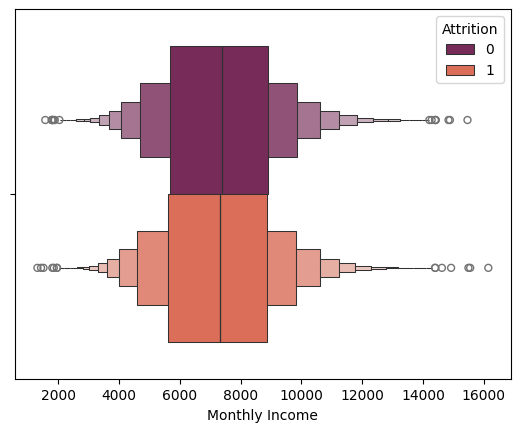

In [17]:
sns.boxenplot(data=train_df, x='Monthly Income', hue='Attrition', palette = 'rocket')
plt.show()

We see that on the right side detected outliers are approximately > 14000, while on the left are approx. < 2100. So lets look on this instances

In [18]:
train_df_catboost.loc[train_df['Monthly Income'] > 14000].sample(5) # We use train_df_catboost since it looks better that train_df with just numbers

,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Education Level,Marital Status,Job Level,Company Size,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
39740,57,Male,8,Finance,14002,Excellent,High,Average,2,No,...,Master’s Degree,Single,Mid,Medium,No,No,No,Good,Low,0
10962,43,Male,27,Finance,14066,Fair,High,Below Average,0,No,...,Bachelor’s Degree,Single,Entry,Medium,No,No,No,Fair,High,1
40520,23,Male,3,Finance,14076,Fair,Medium,Average,0,No,...,High School,Married,Senior,Large,Yes,No,Yes,Fair,Medium,0
43730,27,Female,3,Finance,14103,Fair,Medium,Average,0,No,...,Associate Degree,Married,Entry,Medium,No,No,No,Poor,Low,1
35324,32,Male,5,Technology,14286,Excellent,High,High,2,Yes,...,High School,Married,Mid,Medium,No,No,No,Poor,Medium,0


In [19]:
train_df_catboost.loc[train_df['Monthly Income'] > 14000].shape[0]

33

We can clearly see that these outliers (>14000) are related to the people that work in finance and technology. Thus we can conclude that for these industries such a salary may not be an outlier which will cause overfitting and poorer predictive power of our model, but the real-life situation that can happen. Hence, we will not touch them at all.

In [20]:
train_df_catboost.loc[train_df['Monthly Income'] <= 2100].sample(5)

,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Education Level,Marital Status,Job Level,Company Size,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
38176,42,Female,9,Education,1960,Fair,Very High,Average,1,No,...,Associate Degree,Single,Entry,Small,Yes,No,No,Good,Medium,1
11313,27,Male,17,Education,1847,Excellent,High,Average,0,No,...,Associate Degree,Married,Mid,Small,No,No,No,Excellent,High,0
395,36,Female,7,Education,2075,Good,High,Below Average,2,Yes,...,Bachelor’s Degree,Single,Mid,Small,No,No,No,Good,High,1
18907,38,Male,10,Education,2035,Good,High,Average,0,No,...,Associate Degree,Married,Entry,Large,No,No,Yes,Fair,Low,1
25171,41,Male,26,Education,2094,Fair,Medium,Average,0,No,...,Associate Degree,Single,Mid,Small,Yes,No,No,Fair,Medium,0


Here we see that most of these instances are for people from Education industry. Thus, we can easily assume that such situation is also a 'real-life' thing so we don't need to drop out these outliers

In [21]:
# Getting the initial X matrix before feature engineering
X_initial = train_df.drop(columns=['Attrition'])
y = train_df.Attrition
X_initial.head()

,Age,Years at Company,Monthly Income,Distance from Home,Work-Life Balance,Job Satisfaction,Performance Rating,Education Level,Job Level,Company Size,...,Marital Status_Married,Marital Status_Single,Overtime_Yes,Gender_Male,Remote Work_Yes,Job Role_Finance,Job Role_Healthcare,Job Role_Media,Job Role_Technology,Innovation Opportunities_Yes
0,31,19,5390,22,3.0,1.0,2.0,1.0,1.0,1.0,...,True,False,False,True,False,False,False,False,False,False
1,59,4,5534,21,0.0,2.0,0.0,3.0,1.0,1.0,...,False,False,False,False,False,False,False,True,False,False
2,24,10,8159,11,2.0,2.0,0.0,2.0,1.0,1.0,...,True,False,False,False,False,False,True,False,False,False
3,36,7,3989,27,2.0,2.0,3.0,0.0,1.0,0.0,...,False,True,False,False,True,False,False,False,False,False
4,56,41,4821,71,1.0,3.0,2.0,0.0,2.0,1.0,...,False,False,True,True,False,False,False,False,False,False


Now we can work on creating new features

In [22]:
def new_features_creation(df):
  # We will make new dataframe for our new features
  new_features_df = pd.DataFrame()
  # Promotion rate (promotions per year at company)
  new_features_df['Promotion Rate'] = df['Number of Promotions'] / (df['Years at Company'])

  # Time since last promotion (basically inverse of promotion rate)
  new_features_df['Years Per Promotion'] = df['Years at Company'] / (df['Number of Promotions'] + 1) # Here we need + 1 since we have some 'num of promotions' equal to 0

  # Career 'stagnation' indicator (more than 5 years without promotions)
  new_features_df['Stagnation'] = ((df['Years at Company'] > 5) & (df['Number of Promotions'] == 0))

  # Income adequacy score (here we just want to compare to the median salary by the job level and see whether it is adequate(>1) or not(<1) - generally more than the market or not)
  new_features_df['Income Adequacy Ratio'] = df['Monthly Income'] / df.groupby('Job Level')['Monthly Income'].transform('median')

  # Also we have a hypothesis that generation Z (like we are) are more prone to change the work (we think we have more time and usually are not burden with family staff yet)
  # so we want to make a new group (dummy variable) for zoomers only
  new_features_df['Zoomer'] = df['Age'].apply(lambda x: True if x <= 28 else False)

  # Performance - recognition alignment (closer to 0 - more aligned (good performance - high recognition = 0))
  new_features_df['Recognition Gap'] = df['Performance Rating'] - df['Employee Recognition']

  # 'Perfect worker' (has high performance rating (= 3), great education (>= 3) and leadership opportunities(1))
  new_features_df['Perfect Worker'] = ((df['Performance Rating'] == 3) & (df['Education Level'] >= 3) &  (df['Leadership Opportunities_Yes'] == 1)) # There are just 147 of them for train

  return new_features_df

In [23]:
# Now lets look on this newly created dataset
new_features_df_train = new_features_creation(train_df)
new_features_df_train.head()

,Promotion Rate,Years Per Promotion,Stagnation,Income Adequacy Ratio,Zoomer,Recognition Gap,Perfect Worker
0,0.105263,6.333333,False,0.736138,False,1.0,False
1,0.750000,1.000000,False,0.755804,False,0.0,False
2,0.000000,10.000000,True,1.114313,True,0.0,False
3,0.142857,3.500000,False,0.544797,False,2.0,False
4,0.000000,41.000000,True,0.656008,False,1.0,False


In [24]:
# Now stack train_df with this dataset
train_df = pd.concat([train_df, new_features_df_train], axis=1)

# Now get new X matrix
X_new_features = train_df.drop(columns=['Attrition'])
X_new_features.head()

,Age,Years at Company,Monthly Income,Distance from Home,Work-Life Balance,Job Satisfaction,Performance Rating,Education Level,Job Level,Company Size,...,Job Role_Media,Job Role_Technology,Innovation Opportunities_Yes,Promotion Rate,Years Per Promotion,Stagnation,Income Adequacy Ratio,Zoomer,Recognition Gap,Perfect Worker
0,31,19,5390,22,3.0,1.0,2.0,1.0,1.0,1.0,...,False,False,False,0.105263,6.333333,False,0.736138,False,1.0,False
1,59,4,5534,21,0.0,2.0,0.0,3.0,1.0,1.0,...,True,False,False,0.750000,1.000000,False,0.755804,False,0.0,False
2,24,10,8159,11,2.0,2.0,0.0,2.0,1.0,1.0,...,False,False,False,0.000000,10.000000,True,1.114313,True,0.0,False
3,36,7,3989,27,2.0,2.0,3.0,0.0,1.0,0.0,...,False,False,False,0.142857,3.500000,False,0.544797,False,2.0,False
4,56,41,4821,71,1.0,3.0,2.0,0.0,2.0,1.0,...,False,False,False,0.000000,41.000000,True,0.656008,False,1.0,False


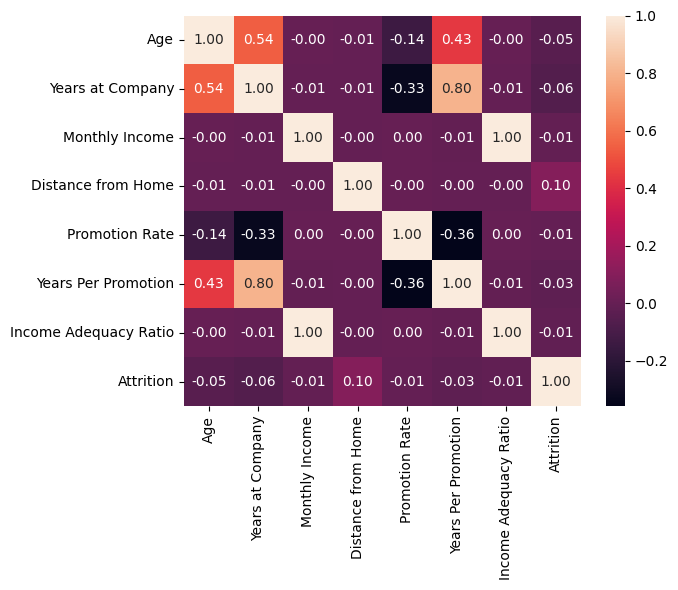

In [25]:
# Now we have to look on the new correlation matrix
num_columns_new = num_columns + ['Promotion Rate', 'Years Per Promotion', 'Income Adequacy Ratio', 'Attrition']

plt.figure(figsize=(7,6))
sns.heatmap(train_df[num_columns_new].corr(), cmap=sns.color_palette('rocket', as_cmap=True), annot=True, fmt='.2f')
plt.tight_layout()
plt.savefig('Heatmap 2', dpi=800, bbox_inches='tight')
plt.show()

In [26]:
# Now also look at mutual information for binary variables
from sklearn.feature_selection import mutual_info_classif
binary_columns = train_df.select_dtypes('bool').columns
mutual_information = mutual_info_classif(train_df[binary_columns], y)

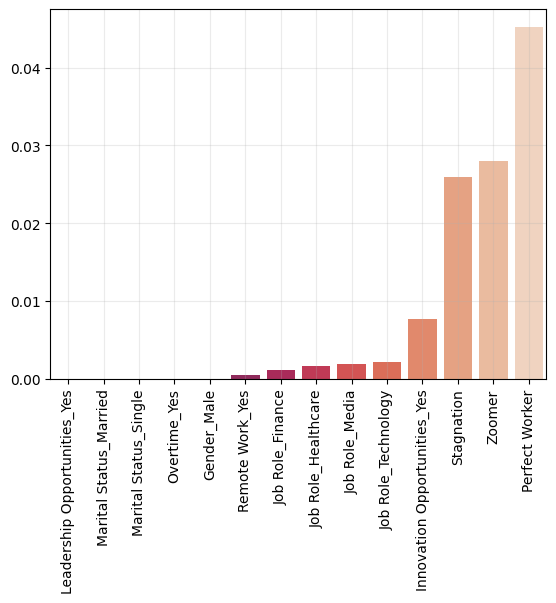

In [27]:
mutual_information = np.array(sorted(mutual_information)).reshape(1,-1)
mut_info_df = pd.DataFrame(columns=binary_columns, data=mutual_information)
sns.barplot(data=mut_info_df, palette = 'rocket')
plt.grid(alpha=0.25)
plt.xticks(rotation=90)
plt.savefig('MU binary', dpi=800, bbox_inches='tight')
plt.show()

In [28]:
mutual_information_ordinal = mutual_info_classif(train_df[ordinal_columns], y)
mutual_information_ordinal

array([0.0244868 , 0.00428553, 0.00710595, 0.00680808, 0.0574027 ,
       0.00366883, 0.01239386, 0.00043683, 0.00876759])

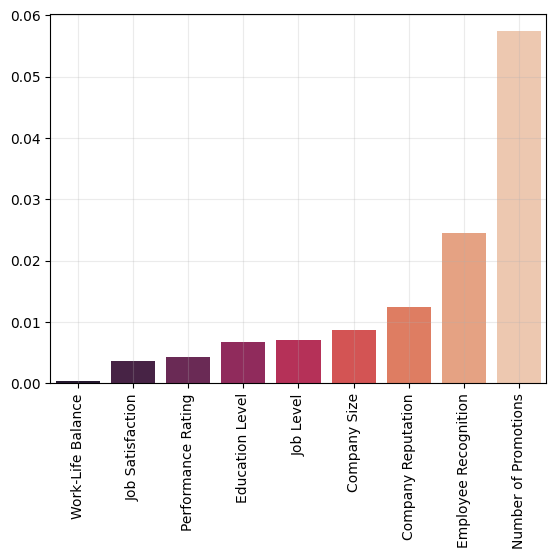

In [29]:
mutual_information_ordinal = np.array(sorted(mutual_information_ordinal)).reshape(1,-1)
mut_info_ordinal_df = pd.DataFrame(columns=ordinal_columns, data=mutual_information_ordinal)
sns.barplot(data=mut_info_ordinal_df, palette = 'rocket')
plt.grid(alpha=0.25)
plt.xticks(rotation=90)
plt.savefig('MU ordinal', dpi=800, bbox_inches='tight')
plt.show()

Obviously now we have some multicorrelated variables - the ones which are connected with age, i.e., 'Years at Company', 'Years Per Promotion' and 'Age'.
Thus, we can make a new variable which will refer to this group of variables using simple PCA

In [30]:
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
years_pca = pca.fit_transform(train_df[['Years at Company', 'Years Per Promotion', 'Age']])
pca.explained_variance_ratio_

array([0.72412218])

We see that quite a lot of information was lost. Yet the thing is that we didn't want to save this information in order just to reduce the dimensionality, insted we wanted to make a new feature that will represent this group of features

In [31]:
X_pca = X_new_features.loc[:,:].drop(columns=['Years at Company', 'Years Per Promotion', 'Age'])
X_pca['YearsPCA'] = years_pca

In [32]:
X_pca.head()

,Monthly Income,Distance from Home,Work-Life Balance,Job Satisfaction,Performance Rating,Education Level,Job Level,Company Size,Company Reputation,Employee Recognition,...,Job Role_Media,Job Role_Technology,Innovation Opportunities_Yes,Promotion Rate,Stagnation,Income Adequacy Ratio,Zoomer,Recognition Gap,Perfect Worker,YearsPCA
0,5390,22,3.0,1.0,2.0,1.0,1.0,1.0,3.0,1.0,...,False,False,False,0.105263,False,0.736138,False,1.0,False,-4.841646
1,5534,21,0.0,2.0,0.0,3.0,1.0,1.0,1.0,0.0,...,True,False,False,0.750000,False,0.755804,False,0.0,False,-0.381784
2,8159,11,2.0,2.0,0.0,2.0,1.0,1.0,0.0,0.0,...,False,False,False,0.000000,True,1.114313,True,0.0,False,-12.750988
3,3989,27,2.0,2.0,3.0,0.0,1.0,0.0,2.0,1.0,...,False,False,False,0.142857,False,0.544797,False,2.0,False,-10.835962
4,4821,71,1.0,3.0,2.0,0.0,2.0,1.0,1.0,1.0,...,False,False,False,0.000000,True,0.656008,False,1.0,False,41.337567


Hence we have three X matrices for our model fitting - X_initial, X_new_features and X_pca. Thus, for the next section we will use all of them, build models and compare. Firstly, we will experiment on the Logistic regression to test whether the relation is linear and then use nonparametric models such as decision tree and later ensembles and neural networks to account for potential non-linearities  

# Model Training

As was prevously mentioned, we will train logistic regression on our three datasets using cross-validation. Then, we will tune the model using the dataset with the highest score on cross-validation. As for the metric to test the qualility, we will use recall-score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score,classification_report

In [ ]:
X_matrices = [X_initial, X_new_features, X_pca]
p1_logistic = Pipeline([
    ('scaler', StandardScaler()), # Standard scaler will work since we dont have outliers (at least 'bad' ones)
    ('model', LogisticRegression()) # Firstly we will train it on default parametes
    ])
recall_scores_cv = []
for X_matrix in X_matrices:
  clf = p1_logistic
  scores = cross_val_score(clf, X_matrix, y, cv=3, scoring='recall', n_jobs=-1)
  recall_scores_cv.append(scores.mean())
for score, matrix in zip(recall_scores_cv, X_matrices):
  print(f'cross-val recall score on {matrix.columns} is {score}')
  print()

cross-val recall score on Index(['Age', 'Years at Company', 'Monthly Income', 'Distance from Home',
       'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
       'Education Level', 'Job Level', 'Company Size', 'Company Reputation',
       'Employee Recognition', 'Number of Promotions',
       'Leadership Opportunities_Yes', 'Innovation Opportunities_Yes',
       'Job Role_Finance', 'Job Role_Healthcare', 'Job Role_Media',
       'Job Role_Technology', 'Marital Status_Married',
       'Marital Status_Single', 'Overtime_Yes', 'Remote Work_Yes',
       'Gender_Male'],
      dtype='object') is 0.7183287458536242

cross-val recall score on Index(['Age', 'Years at Company', 'Monthly Income', 'Distance from Home',
       'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
       'Education Level', 'Job Level', 'Company Size', 'Company Reputation',
       'Employee Recognition', 'Number of Promotions',
       'Leadership Opportunities_Yes', 'Innovation Opportunities_Y

Here we can clearly see, that adding new features improves the quality of the model. What's more important - using PCA also helps us to improve recall score

In [ ]:
# Now we move to the model tuning using GridSearch
p2_gs_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=500, random_state=42, solver='liblinear'))
    ])
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2']
}
GS = GridSearchCV(p2_gs_logistic, param_grid, scoring='recall', cv=3, verbose=2, n_jobs=-1)
GS.fit(X_pca, y)
print(GS.best_score_, GS.best_estimator_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ..................model__C=0.001, model__penalty=l1; total time=   0.2s
[CV] END ..................model__C=0.001, model__penalty=l1; total time=   0.2s
[CV] END ..................model__C=0.001, model__penalty=l1; total time=   0.2s
[CV] END ..................model__C=0.001, model__penalty=l2; total time=   0.4s
[CV] END ..................model__C=0.001, model__penalty=l2; total time=   0.4s
[CV] END ..................model__C=0.001, model__penalty=l2; total time=   0.4s
[CV] END ...................model__C=0.01, model__penalty=l1; total time=   0.3s
[CV] END ...................model__C=0.01, model__penalty=l1; total time=   0.3s
[CV] END ...................model__C=0.01, model__penalty=l1; total time=   0.3s
[CV] END ...................model__C=0.01, model__penalty=l2; total time=   0.5s
[CV] END ...................model__C=0.01, model__penalty=l2; total time=   0.5s
[CV] END ...................model__C=0.01, model

We were able to increase our recal score using grid search!

In [ ]:
# To use it after we reconnect to the enviroment
best_estimator_log_reg = Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(C=0.001, max_iter=500, penalty='l1', random_state=42, solver='liblinear'))])

In [ ]:
# Now we fit the best model
logistic_regression_pipeline = best_estimator_log_reg
logistic_regression_pipeline.fit(X_pca, y)
try:
    check_is_fitted(logistic_regression_pipeline)
    print('Pipeline is fitted')
except:
    print('Pipeline is not fitted')

# Just some kind of check

Pipeline is fitted


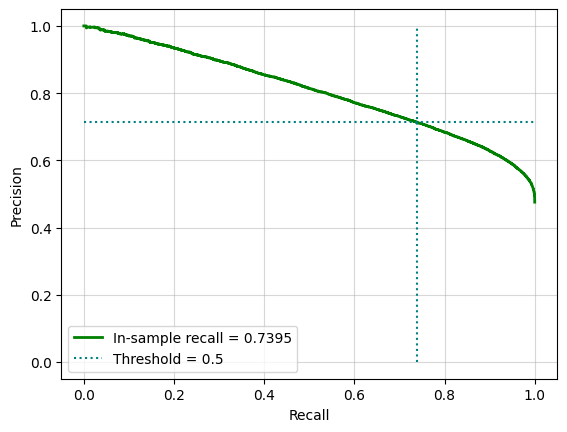

In [ ]:
# Now we check our in-sample predictions
y_pred_train = logistic_regression_pipeline.predict_proba(X_pca)[:, 1]
precision, recall, thresholds = precision_recall_curve(y, y_pred_train)
index_threshold = np.where(thresholds >= 0.5)[0][0]
plt.plot(recall, precision, linewidth=2, label='Precision/Recall curve', color='g')
plt.vlines(recall[index_threshold], 0, 1., 'teal', 'dotted', label='threshold')
plt.hlines(precision[index_threshold], 0, 1., 'teal', 'dotted', label='threshold')
plt.grid(alpha=0.5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend([f'In-sample recall = {recall_score(y, [1 if x >= 0.5 else 0 for x in y_pred_train]):.4f}', f'Threshold = {0.5}'], loc='lower left')
plt.show()

Interesting thing that we can see here - in-sample recal score is even less than during cross-validation! One of the possible reasons for that - we have quite a strong regularization (penalty = l1, C = 0.001)

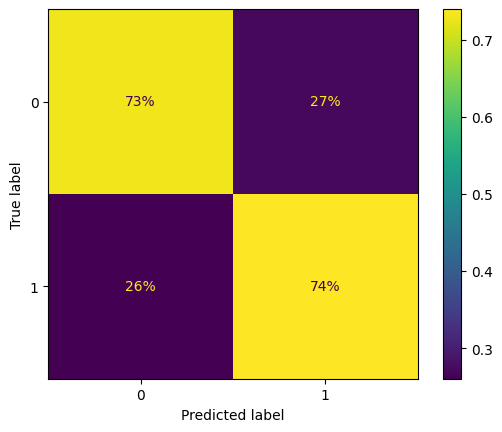

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y, [1 if x >= 0.5 else 0 for x in y_pred_train], normalize='true', values_format='.0%')
plt.show()

So we see that our model is equally confused with both people that left and people that stayed

In [ ]:
model = logistic_regression_pipeline.named_steps['model']
dict_coefs_logreg = {feature: coef for feature, coef in zip(X_pca.columns, model.coef_[0])}
dict_coefs_logreg

{'Monthly Income': np.float64(0.0),
 'Distance from Home': np.float64(0.15165284120001749),
 'Work-Life Balance': np.float64(-0.38389773005918576),
 'Job Satisfaction': np.float64(0.0),
 'Performance Rating': np.float64(-0.035866772030020366),
 'Education Level': np.float64(-0.0334760256024387),
 'Job Level': np.float64(-0.6906600799085489),
 'Company Size': np.float64(0.0),
 'Company Reputation': np.float64(-0.17629317026843253),
 'Employee Recognition': np.float64(0.0),
 'Number of Promotions': np.float64(-0.12731458418505595),
 'Leadership Opportunities_Yes': np.float64(0.0),
 'Overtime_Yes': np.float64(0.052824210875805404),
 'Remote Work_Yes': np.float64(-0.47798881458519327),
 'Marital Status_Married': np.float64(-0.0590340933695166),
 'Marital Status_Single': np.float64(0.5720272846390279),
 'Innovation Opportunities_Yes': np.float64(0.0),
 'Job Role_Finance': np.float64(0.0),
 'Job Role_Healthcare': np.float64(0.0),
 'Job Role_Media': np.float64(0.0),
 'Job Role_Technology': np

In [ ]:
# Checking which features are non-zero
non_zero_features = []
non_zero_coefs = []
for feature, coef in dict_coefs_logreg.items():
  if coef != 0:
    non_zero_features.append(feature)
    non_zero_coefs.append(coef)
dict_coefs_non_zero = {feature: float(coef) for feature, coef in zip(non_zero_features, non_zero_coefs)}
dict_coefs_non_zero

{'Distance from Home': 0.15165284120001749,
 'Work-Life Balance': -0.38389773005918576,
 'Performance Rating': -0.035866772030020366,
 'Education Level': -0.0334760256024387,
 'Job Level': -0.6906600799085489,
 'Company Reputation': -0.17629317026843253,
 'Number of Promotions': -0.12731458418505595,
 'Overtime_Yes': 0.052824210875805404,
 'Remote Work_Yes': -0.47798881458519327,
 'Marital Status_Married': -0.0590340933695166,
 'Marital Status_Single': 0.5720272846390279,
 'Gender_Male': -0.17023316717289017,
 'Zoomer': 0.03437841413699834,
 'YearsPCA': -0.058031728749890786}

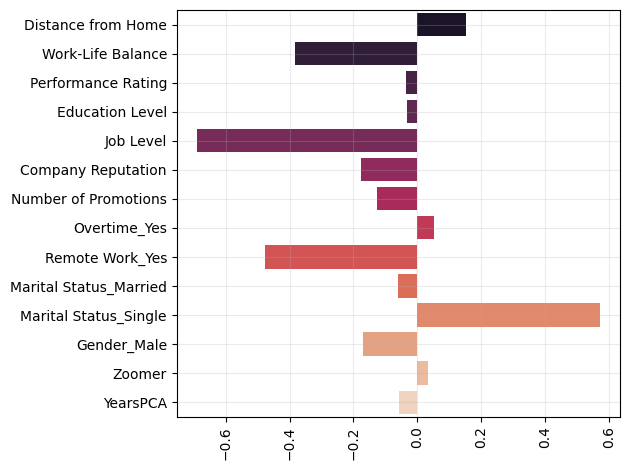

In [ ]:
sns.barplot(y=non_zero_features, x=non_zero_coefs, palette='rocket')
plt.grid(alpha=0.25)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Logreg importances', dpi=800, bbox_inches='tight')
plt.show()

There are several things that should be mentioned based on the graph above:

1) The strongest positive effect has a dummy variable which refers to the single people;
2) The strongest negative effect has a 'job level' variable;
3) From the new features we created only binary variable 'Zoomer' and 'YearsPCA' turned out to be important

In [ ]:
# Now we move to decision tree classifier
X_matrices = [X_initial, X_new_features, X_pca]
p1_tree = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42)) # Since trees do not really care about data scaling, we will not do it
    ])

for X_matrix in X_matrices:
  clf = p1_tree
  scores = cross_val_score(clf, X_matrix, y, cv=3, scoring='recall', n_jobs=-1)
  print(f'Recall score on {X_matrix.columns} is {scores.mean()}')
  print()

Recall score on Index(['Age', 'Years at Company', 'Monthly Income', 'Distance from Home',
       'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
       'Education Level', 'Job Level', 'Company Size', 'Company Reputation',
       'Employee Recognition', 'Number of Promotions',
       'Leadership Opportunities_Yes', 'Innovation Opportunities_Yes',
       'Job Role_Finance', 'Job Role_Healthcare', 'Job Role_Media',
       'Job Role_Technology', 'Marital Status_Married',
       'Marital Status_Single', 'Overtime_Yes', 'Remote Work_Yes',
       'Gender_Male'],
      dtype='object') is 0.6416825464041217

Recall score on Index(['Age', 'Years at Company', 'Monthly Income', 'Distance from Home',
       'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
       'Education Level', 'Job Level', 'Company Size', 'Company Reputation',
       'Employee Recognition', 'Number of Promotions',
       'Leadership Opportunities_Yes', 'Innovation Opportunities_Yes',
       'Job Rol

First of all, our non-linear (default) model is worse than linear!!!

Secondly, we again see that dataset with new features and with one PCA variable has the best recall score, so we will use it to tune the model

In [ ]:
p2_gs_tree = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
    ])
param_grid = {
    'model__splitter' : ['best', 'random'],
    'model__max_depth': np.arange(2, 22, 2),
    'model__min_samples_split' : np.arange(5, 40, 5),
    'model__max_features' : [0.5, 'sqrt', 'log2']
}
GS = GridSearchCV(p2_gs_tree, param_grid, scoring='recall', cv=3, verbose=2, n_jobs=-1)
GS.fit(X_pca, y)
print(GS.best_score_, GS.best_estimator_)

Fitting 3 folds for each of 420 candidates, totalling 1260 fits
0.8805137977274331 Pipeline(steps=[('model',
                 DecisionTreeClassifier(max_depth=np.int64(2),
                                        max_features='log2',
                                        min_samples_split=np.int64(5),
                                        random_state=42, splitter='random'))])


In [ ]:
best_estimator_tree = Pipeline(steps=[('model',
                 DecisionTreeClassifier(max_depth=np.int64(2),
                                        max_features='log2',
                                        min_samples_split=np.int64(5),
                                        random_state=42, splitter='random'))])

We get an increase by almost 0.14 from the logistic regression after tunnig (and we got this just on random splitting!)

In [ ]:
# Now we fit the best model
decision_tree_pipeline = best_estimator_tree
decision_tree_pipeline.fit(X_pca, y)
try:
    check_is_fitted(decision_tree_pipeline)
    print('Pipeline is fitted')
except:
    print('Pipeline is not fitted')

Pipeline is fitted


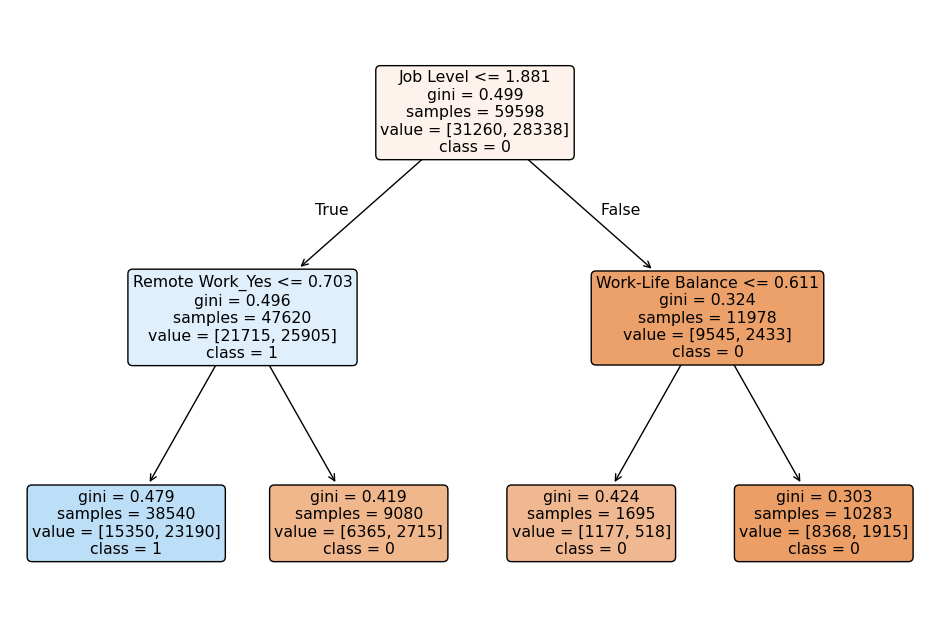

In [ ]:
# We can plot the tree
plt.figure(figsize=(12, 8))
plot_tree(decision_tree_pipeline.named_steps['model'],
          feature_names=X_pca.columns,
          class_names=['0', '1'],
          filled=True,
          rounded=True)
plt.savefig('Tree', dpi=800, bbox_inches='tight')
plt.show()

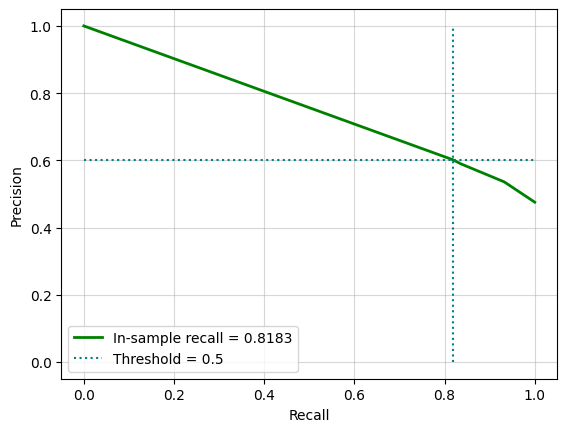

In [ ]:
# Now we check our in-sample predictions
y_pred_train = decision_tree_pipeline.predict_proba(X_pca)[:, 1]
precision, recall, thresholds = precision_recall_curve(y, y_pred_train)
index_threshold = np.where(thresholds >= 0.5)[0][0]
plt.plot(recall, precision, linewidth=2, label='Precision/Recall curve', color='g')
plt.vlines(recall[index_threshold], 0, 1., 'teal', 'dotted', label='threshold')
plt.hlines(precision[index_threshold], 0, 1., 'teal', 'dotted', label='threshold')
plt.grid(alpha=0.5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend([f'In-sample recall = {recall_score(y, [1 if x >= 0.5 else 0 for x in y_pred_train]):.4f}', f'Threshold = {0.5}'], loc='lower left')
plt.show()

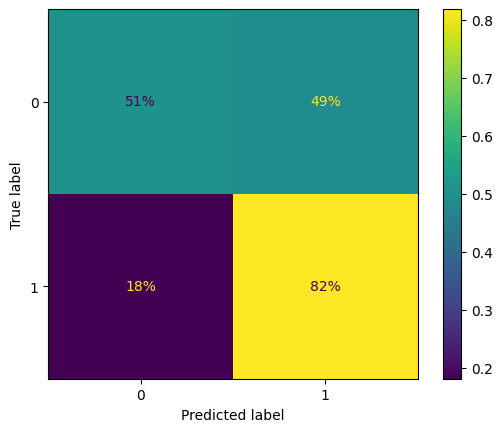

In [ ]:
ConfusionMatrixDisplay.from_predictions(y, [1 if x >= 0.5 else 0 for x in y_pred_train], normalize='true', values_format='.0%')
plt.show()

However, this tree has one clear problem - it is most often mistaken with people who stayed. Hence, it is somewhat overfitted to the chosen metric. In order to work with that we will try to grid search for the parameters with another scoring - f1_score and see how the inference will change

In [ ]:
# New grid search using f1
p3_gs_tree = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
    ])
param_grid = {
    'model__splitter' : ['best', 'random'],
    'model__max_depth': np.arange(2, 22, 2),
    'model__min_samples_split' : np.arange(5, 40, 5),
    'model__max_features' : [0.5, 'sqrt', 'log2']
}
GS_f1 = GridSearchCV(p2_gs_tree, param_grid, scoring='f1', cv=3, verbose=2, n_jobs=-1)
GS_f1.fit(X_pca, y)
print(GS_f1.best_score_, GS_f1.best_estimator_)

Fitting 3 folds for each of 420 candidates, totalling 1260 fits
0.730994545303186 Pipeline(steps=[('model',
                 DecisionTreeClassifier(max_depth=np.int64(6), max_features=0.5,
                                        min_samples_split=np.int64(25),
                                        random_state=42))])


In [ ]:
best_estimator_tree_f1 = Pipeline(steps=[('model',
                 DecisionTreeClassifier(max_depth=np.int64(6), max_features=0.5,
                                        min_samples_split=np.int64(25),
                                        random_state=42))])

In [ ]:
decision_tree_pipeline_f1 = best_estimator_tree_f1
decision_tree_pipeline_f1.fit(X_pca, y)

Pipeline(steps=[('model',
                 DecisionTreeClassifier(max_depth=np.int64(6), max_features=0.5,
                                        min_samples_split=np.int64(25),
                                        random_state=42))])

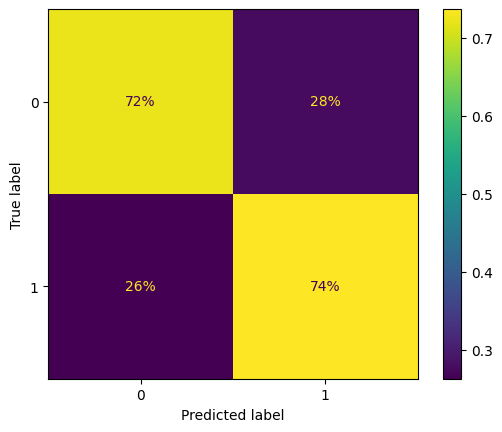

In [ ]:
y_pred_train_f1 = decision_tree_pipeline_f1.predict_proba(X_pca)[:, 1]
ConfusionMatrixDisplay.from_predictions(y, [1 if x >= 0.5 else 0 for x in y_pred_train_f1], normalize='true', values_format='.0%')
plt.show()

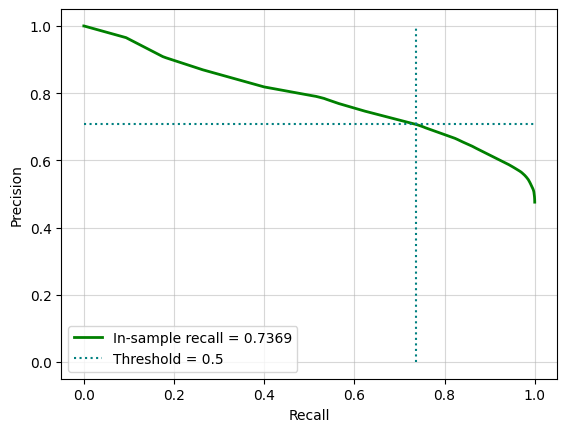

In [ ]:
precision, recall, thresholds = precision_recall_curve(y, y_pred_train_f1)
index_threshold = np.where(thresholds >= 0.5)[0][0]
plt.plot(recall, precision, linewidth=2, label='Precision/Recall curve', color='g')
plt.vlines(recall[index_threshold], 0, 1., 'teal', 'dotted', label='threshold')
plt.hlines(precision[index_threshold], 0, 1., 'teal', 'dotted', label='threshold')
plt.grid(alpha=0.5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend([f'In-sample recall = {recall_score(y, [1 if x >= 0.5 else 0 for x in y_pred_train_f1]):.4f}', f'Threshold = {0.5}'], loc='lower left')
plt.show()

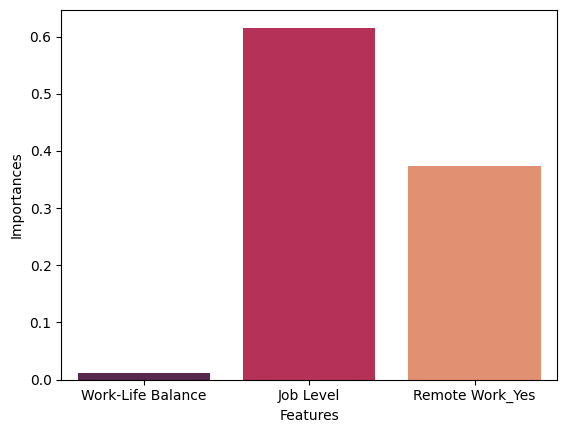

In [ ]:
# Now look at the feature importances of the both trees
# For initial tree
feature_importances = decision_tree_pipeline.named_steps['model'].feature_importances_
non_zero_importances = np.where(feature_importances > 0)[0]
important_features = X_pca.columns[non_zero_importances]
sns.barplot(x=important_features, y=feature_importances[non_zero_importances], palette='rocket')
plt.xlabel('Features')
plt.ylabel('Importances')
plt.show()

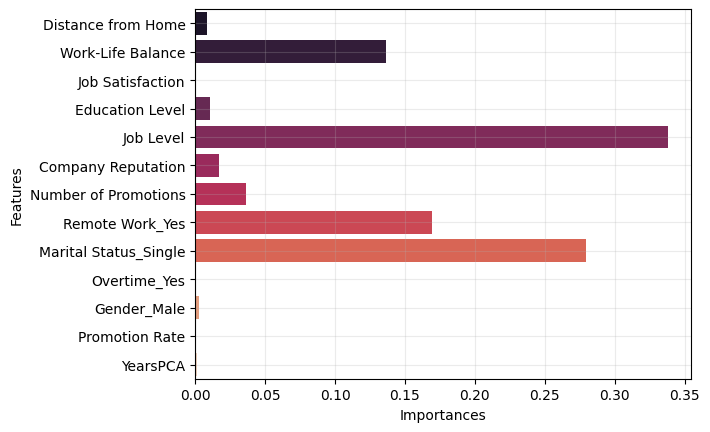

In [ ]:
# For the 'f1-tree'
feature_importances = decision_tree_pipeline_f1.named_steps['model'].feature_importances_
non_zero_importances = np.where(feature_importances > 0)[0]
important_features = X_pca.columns[non_zero_importances]
sns.barplot(x=feature_importances[non_zero_importances], y=important_features, palette='rocket')
plt.grid(alpha=0.25)
plt.xlabel('Importances')
plt.ylabel('Features')
plt.show()

We again have 'Job Level' and 'Single' as the most important features

Now we are ready to make inference on three models

# Inference

For inference we have to do the same preprocessing as before but with 'transform' method

In [ ]:
test_df = pd.read_csv('test_attrition.csv')

In [ ]:
test_df['Number of Promotions'] = test_df['Number of Promotions'].astype('object')
test_df = test_df.drop(columns=['Number of Dependents', 'Company Tenure', 'Employee ID'])
test_df['Attrition'] = test_df['Attrition'].apply(lambda x: 1 if x == 'Left' else 0)
test_df_catboost = test_df

In [ ]:
ordinal_encoded_test = ordinal_encoder.transform(test_df[ordinal_columns])
ordinal_encoded_df_test = pd.DataFrame(columns=feature_names, data=ordinal_encoded_test)

ohe_fitted_test = ohe.transform(test_df[ohe_columns])
ohe_encoded_df_test = pd.DataFrame(columns=feature_names_ohe, data=ohe_fitted_test)

test_df = test_df.drop(columns=ordinal_columns)
test_df = test_df.drop(columns=ohe_columns)
test_df = pd.concat([test_df, ordinal_encoded_df_test, ohe_encoded_df_test], axis=1)

new_features_df_test = new_features_creation(test_df)

test_df = pd.concat([test_df, new_features_df_test], axis=1)
X_test_new_features = test_df.drop(columns=['Attrition'])
X_test_new_features

,Age,Years at Company,Monthly Income,Distance from Home,Work-Life Balance,Job Satisfaction,Performance Rating,Education Level,Job Level,Company Size,...,Job Role_Media,Job Role_Technology,Gender_Male,Promotion Rate,Years Per Promotion,Stagnation,Income Adequacy Ratio,Zoomer,Recognition Gap,Perfect Worker
0,36,13,8029,83,3.0,2.0,2.0,3.0,1.0,2.0,...,False,False,True,0.076923,6.50,False,1.093273,False,1.0,False
1,35,7,4563,55,2.0,2.0,2.0,1.0,0.0,1.0,...,False,False,True,0.142857,3.50,False,0.623787,False,0.0,False
2,50,7,5583,14,1.0,2.0,2.0,1.0,2.0,1.0,...,False,False,True,0.428571,1.75,False,0.760368,False,2.0,False
3,58,44,5525,43,1.0,3.0,3.0,3.0,0.0,1.0,...,True,False,True,0.000000,44.00,True,0.755297,False,3.0,False
4,39,24,4604,47,2.0,2.0,2.0,3.0,1.0,2.0,...,False,False,True,0.000000,24.00,True,0.626906,False,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14895,56,42,7830,40,0.0,1.0,2.0,1.0,2.0,1.0,...,False,False,False,0.000000,42.00,True,1.066394,False,1.0,False
14896,30,15,3856,45,2.0,1.0,2.0,3.0,0.0,1.0,...,False,False,False,0.133333,5.00,False,0.527136,False,1.0,False
14897,52,5,5654,4,2.0,3.0,1.0,1.0,1.0,0.0,...,False,False,True,0.000000,5.00,False,0.769880,False,-1.0,False
14898,18,4,5276,13,1.0,2.0,2.0,2.0,1.0,2.0,...,False,False,True,0.000000,4.00,False,0.718410,True,0.0,False


In [ ]:
years_pca_test = pca.transform(test_df[['Years at Company', 'Years Per Promotion', 'Age']])
X_test_pca = X_test_new_features.loc[:,:].drop(columns=['Years at Company', 'Years Per Promotion', 'Age'])
X_test_pca['YearsPCA'] = years_pca_test
y_test = test_df.Attrition

Now we can predict. We will still use recall score but also will asses accuracy

In [ ]:
from sklearn.metrics import accuracy_score
# Firstly we predict with logistic regression
y_test_pred_logreg = logistic_regression_pipeline.predict(X_test_pca)
print(f'recall score on test is {recall_score(y_test, y_test_pred_logreg)}')
print(f'accuracy score on test is {accuracy_score(y_test, y_test_pred_logreg)}')

recall score on test is 0.7369169510807736
accuracy score on test is 0.7368456375838927


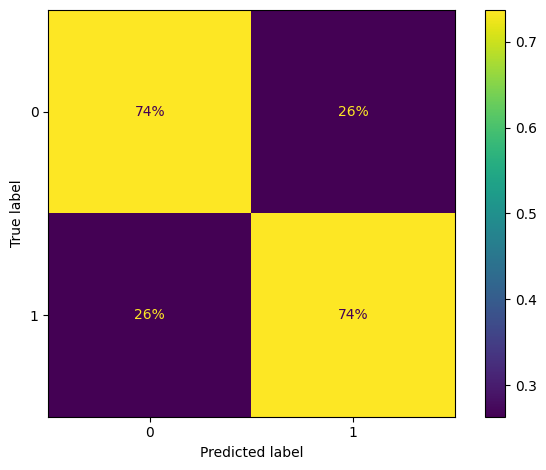

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_logreg, normalize='true', values_format='.0%')
plt.tight_layout()
plt.savefig('Confusion matrix logreg', dpi=800, bbox_inches='tight')
plt.show()

In [ ]:
# Now on the first tree
y_test_pred_tree = decision_tree_pipeline.predict(X_test_pca)
print(f'recall score on test is {recall_score(y_test, y_test_pred_tree)}')
print(f'accuracy score on test is {accuracy_score(y_test, y_test_pred_tree)}')

recall score on test is 0.8205346985210467
accuracy score on test is 0.660268456375839


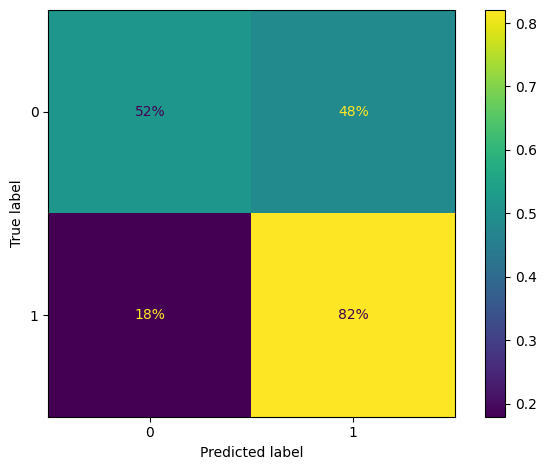

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_tree, normalize='true', values_format='.0%')
plt.tight_layout()
plt.savefig('Confusion matrix tree recall', dpi=800, bbox_inches='tight')
plt.show()

In [ ]:
y_test_pred_tree_f1 = decision_tree_pipeline_f1.predict(X_test_pca)
print(f'recall score on test is {recall_score(y_test, y_test_pred_tree_f1)}')
print(f'accuracy score on test is {accuracy_score(y_test, y_test_pred_tree_f1)}')

recall score on test is 0.7337883959044369
accuracy score on test is 0.731006711409396


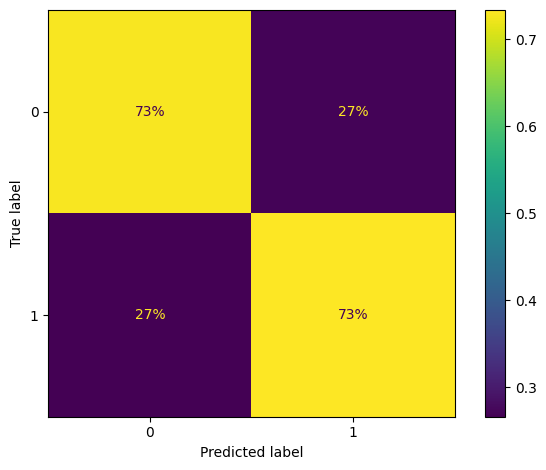

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_tree_f1, normalize='true', values_format='.0%')
plt.tight_layout()
plt.show()

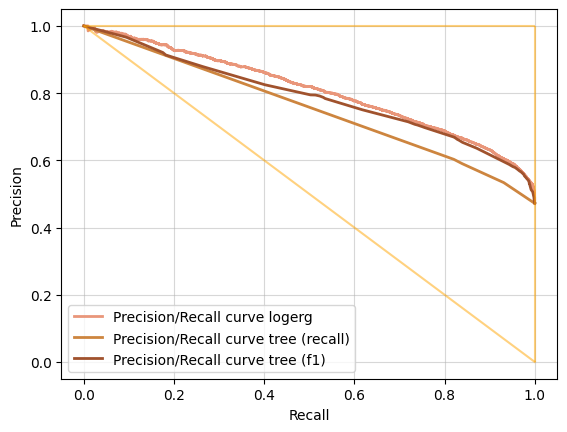

In [ ]:
y_pred_test_logreg = logistic_regression_pipeline.predict_proba(X_test_pca)[:, 1]
y_pred_test_tree = decision_tree_pipeline.predict_proba(X_test_pca)[:, 1]
y_pred_test_tree_f1 = decision_tree_pipeline_f1.predict_proba(X_test_pca)[:, 1]

precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, y_pred_test_logreg)
precision_tree, recall_tree, _ = precision_recall_curve(y_test, y_pred_test_tree)
precision_tree_f1, recall_tree_f1, _ = precision_recall_curve(y_test, y_pred_test_tree_f1)

plt.plot(recall_logreg, precision_logreg, linewidth=2, label='Precision/Recall curve logerg', color='darksalmon')
plt.plot(recall_tree, precision_tree, linewidth=2, label='Precision/Recall curve tree (recall)', color='peru')
plt.plot(recall_tree_f1, precision_tree_f1, linewidth=2, label='Precision/Recall curve tree (f1)', color='sienna')
plt.hlines(1, 0, 1., color='orange', alpha=0.5)
plt.vlines(1, 0, 1., color='orange', alpha=0.5)
plt.plot(np.arange(1, -0.1, -0.1), np.arange(0, 1.1, 0.1), color='orange', alpha=0.5)
plt.grid(alpha=0.5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.savefig('precision-recall', dpi=800, bbox_inches='tight')
plt.show()

# More complex modelling

Firstly, one may notice tha fact that best tree trained on recall has random splitting, which is obviously not stable. Thus, we will firstly consider gridsearch with only 'best' splitting

In [ ]:
# New grid search using best splitting
p4_gs_tree = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
    ])
param_grid = {
    'model__max_depth': np.arange(2, 22, 2),
    'model__min_samples_split' : np.arange(5, 40, 5),
    'model__max_features' : [0.5, 'sqrt', 'log2']
}
GS_best_split = GridSearchCV(p4_gs_tree, param_grid, scoring='recall', cv=3, n_jobs=-1)
GS_best_split.fit(X_pca, y)
print(f'Recall score is {GS_best_split.best_score_}, {GS_best_split.best_estimator_}')

Fitting 3 folds for each of 210 candidates, totalling 630 fits
Recall score is 0.7408779730397347, Pipeline(steps=[('model',
                 DecisionTreeClassifier(max_depth=np.int64(10),
                                        max_features=0.5,
                                        min_samples_split=np.int64(25),
                                        random_state=42))])


We now see that the tree became much more complex comparing to the 'random' split tree. However, now it is stable and will not change splits appeared in the 'best' tree

In [ ]:
best_tree = DecisionTreeClassifier(max_depth=np.int64(10), max_features=0.5, min_samples_split=np.int64(25), random_state=42)

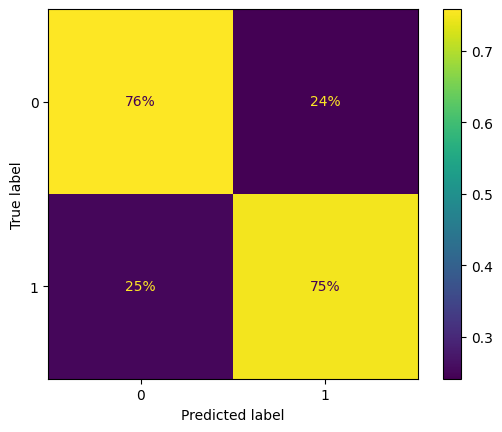

In [ ]:
# The confusion matrix
# best_estimator_tree_best_split = GS_best_split.best_estimator_ # fitted
best_estimator_tree_best_split = best_tree.fit(X_pca, y) # fitted
y_pred_train_best_split = best_estimator_tree_best_split.predict_proba(X_pca)[:, 1]
ConfusionMatrixDisplay.from_predictions(y, [1 if x >= 0.5 else 0 for x in y_pred_train_best_split], normalize='true', values_format='.0%')
plt.show()

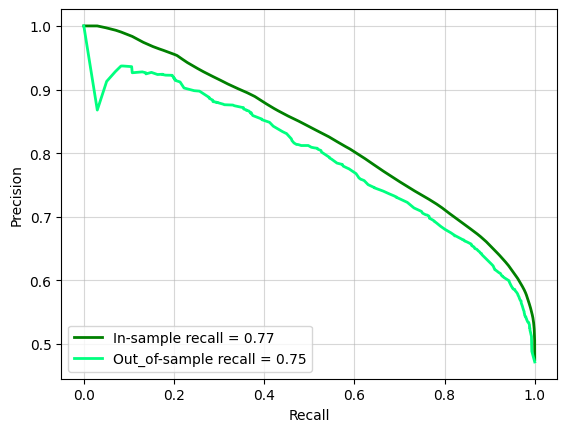

In [ ]:
# Precision-recall score for both train and test
precision_train, recall_train, thresholds_train = precision_recall_curve(y, y_pred_train_best_split)

y_pred_test_best_split = best_estimator_tree_best_split.predict_proba(X_test_pca)[:, 1]
precision_test, recall_test, thresholds_test = precision_recall_curve(y_test, y_pred_test_best_split)

in_sample_recall = recall_score(y, [1 if x >= 0.5 else 0 for x in y_pred_train_best_split])
out_of_sample_recall = recall_score(y_test, [1 if x >= 0.5 else 0 for x in y_pred_test_best_split])

index_threshold_train = np.where(thresholds_train >= 0.5)[0][0]
index_threshold_test = np.where(thresholds_test >= 0.5)[0][0]

plt.plot(recall_train, precision_train, linewidth=2, label='preicion-recall curtve for train', color='green')
plt.plot(recall_test, precision_test, linewidth=2, label='preicion-recall curtve for test', color='springgreen')
# plt.vlines(recall[index_threshold], 0, 1., 'teal', 'dotted', label='threshold')
# plt.hlines(precision[index_threshold], 0, 1., 'teal', 'dotted', label='turqoise')
plt.grid(alpha=0.5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend([f'In-sample recall = {in_sample_recall:.2f}', f'Out_of-sample recall = {out_of_sample_recall:.2f}'], loc='lower left') #, f'Threshold = {0.5}']
plt.show()

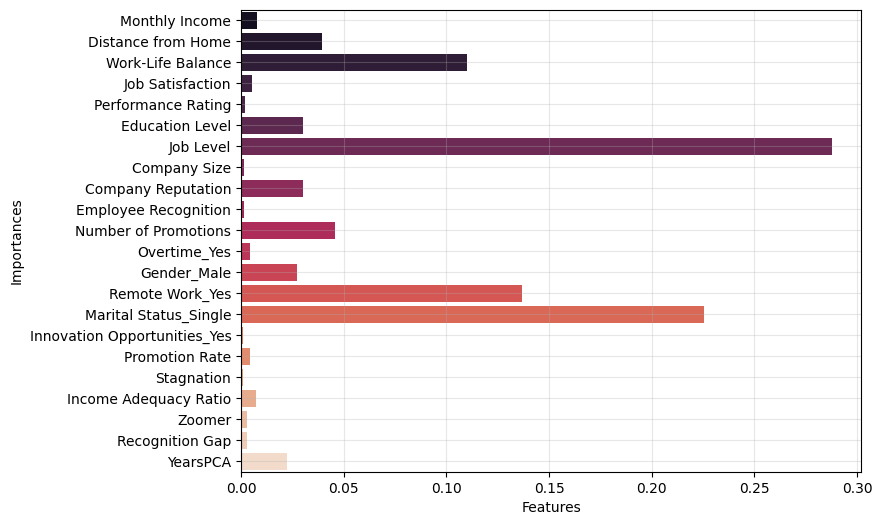

In [ ]:
# We also look on the feature importance
plt.figure(figsize=(8,6))
feature_importances = best_estimator_tree_best_split.named_steps['model'].feature_importances_
non_zero_importances = np.where(feature_importances > 1e-03)[0] # by none zero we mean more than 0.001
important_features = X_pca.columns[non_zero_importances]
sns.barplot(y=important_features, x=feature_importances[non_zero_importances], palette='rocket')
plt.grid(alpha=0.3)
plt.xlabel('Features')
plt.ylabel('Importances')
plt.show()

In [ ]:
# Also will check accuracy
y_test_pred_tree_best_split = best_estimator_tree_best_split.predict(X_test_pca)
print(f'recall score on test is {recall_score(y_test, y_test_pred_tree_best_split)}')
print(f'accuracy score on test is {accuracy_score(y_test, y_test_pred_tree_best_split)}')

recall score on test is 0.7491467576791809
accuracy score on test is 0.7357718120805369


Now we move to ensemble methods and will start with random forest. Also, since ensemble algorithms need lots of time to proceed so we will initially use X_pca as a variable matrix

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Firstly, we train a default classifier and look at its predictive ability
random_forest_1 = RandomForestClassifier(random_state=42)
random_forest_1.fit(X_pca, y)
y_train_prediction_random_forest = random_forest_1.predict(X_pca)
y_test_prediction_random_forest = random_forest_1.predict(X_test_pca)
print(f'In-sample recall = {recall_score(y, y_train_prediction_random_forest)}')
print(f'Out-sample recall {recall_score(y_test, y_test_prediction_random_forest)}')
print(f'In-sample accuracy = {accuracy_score(y, y_train_prediction_random_forest)}')
print(f'Out-sample accuracy {accuracy_score(y_test, y_test_prediction_random_forest)}')

In-sample recall = 1.0
Out-sample recall 0.7201365187713311
In-sample accuracy = 1.0
Out-sample accuracy 0.7467785234899329


What we see is that basically accuracy has increased comparing to one decision tree and logistic regression, however for now recall is smaller since we did not tunned for parameters that would increase it.

Now we will consider step-by-step tunning. Firtsly, we will chose the number of trees in the random forest and only after that we will search for the other hyperparameters (we will also adress potential class imbalance problem)

In [ ]:
num_of_trees = np.arange(50, 525, 25)
recalls_mean = []
recalls_std = []
accuracy_mean = []
accuracy_std = []

for trees in num_of_trees:
  print(f'Current number of trees is {trees}')
  random_forest = RandomForestClassifier(n_estimators=trees, random_state=42, n_jobs=-1)
  cross_validation = cross_validate(estimator=random_forest, X=X_pca, y=y, cv=3, scoring=['recall', 'accuracy'])
  recalls_mean.append(cross_validation['test_recall'].mean())
  recalls_std.append(cross_validation['test_recall'].std())
  accuracy_mean.append(cross_validation['test_accuracy'].mean())
  accuracy_std.append(cross_validation['test_accuracy'].std())

Current number of trees is 50
Current number of trees is 75
Current number of trees is 100
Current number of trees is 125
Current number of trees is 150
Current number of trees is 175
Current number of trees is 200
Current number of trees is 225
Current number of trees is 250
Current number of trees is 275
Current number of trees is 300
Current number of trees is 325
Current number of trees is 350
Current number of trees is 375
Current number of trees is 400
Current number of trees is 425
Current number of trees is 450
Current number of trees is 475
Current number of trees is 500


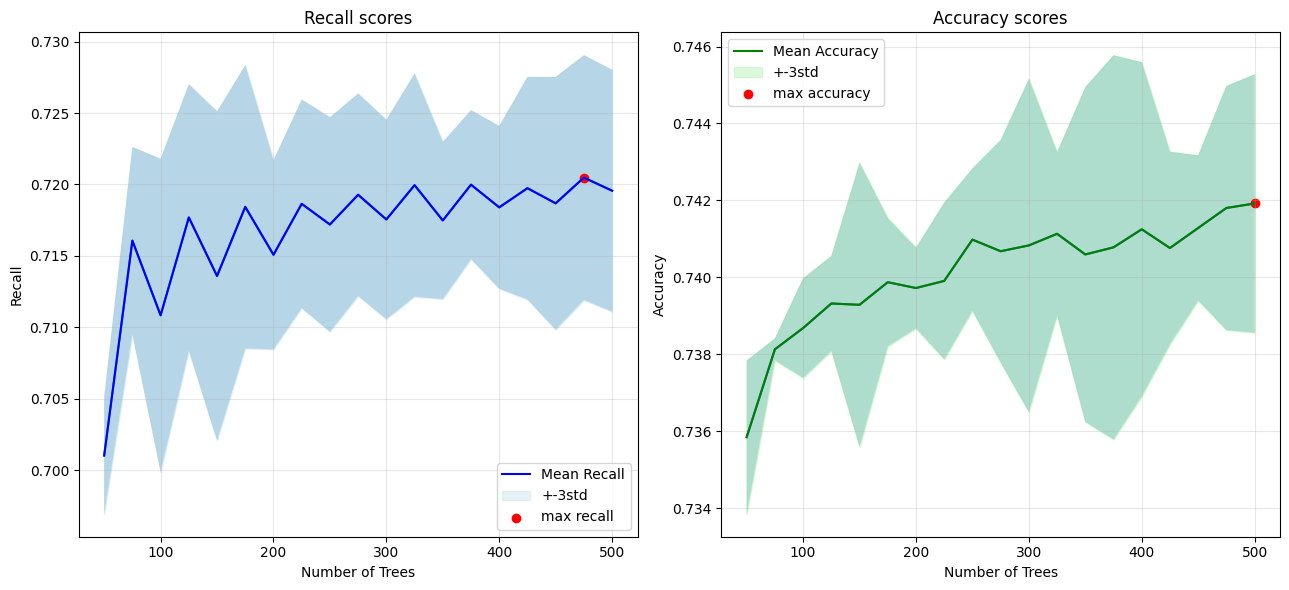

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,6))
recalls_mean_plus_std, recalls_mean_minus_std = np.array(recalls_mean) + 3*np.array(recalls_std), np.array(recalls_mean) - 3*np.array(recalls_std)
accuracy_mean_plus_std, accuracy_mean_minus_std = np.array(accuracy_mean) + 3*np.array(accuracy_std), np.array(accuracy_mean) - 3*np.array(accuracy_std)

axes[0].plot(num_of_trees, recalls_mean)
axes[0].fill_between(num_of_trees, recalls_mean_plus_std, recalls_mean_minus_std, alpha=0.3)

axes[1].plot(num_of_trees, accuracy_mean)
axes[1].fill_between(num_of_trees, accuracy_mean_plus_std, accuracy_mean_minus_std, alpha=0.3)

# Plotting recall on the first subplot
axes[0].plot(num_of_trees, recalls_mean, label='Mean Recall', color='blue')
axes[0].fill_between(num_of_trees, recalls_mean_plus_std, recalls_mean_minus_std, alpha=0.3, label='+-3std', color='lightblue')
axes[0].scatter(num_of_trees[np.argmax(recalls_mean)], max(recalls_mean), label='max recall', color='red')
axes[0].set_title('Recall scores')
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('Recall')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plotting accuracy on the second subplot
axes[1].plot(num_of_trees, accuracy_mean, label='Mean Accuracy', color='green')
axes[1].fill_between(num_of_trees, accuracy_mean_plus_std, accuracy_mean_minus_std, alpha=0.3, label='+-3std', color='lightgreen')
axes[1].scatter(num_of_trees[np.argmax(accuracy_mean)], max(accuracy_mean), label='max accuracy', color='red')
axes[1].set_title('Accuracy scores')
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Scores.png', dpi=600)
plt.show()

We see that it works as it should - RandomForests generally do not overfit badly so the more n_estimators the bigger metrics we use. As we see, the difference between n_estimators=325 and n_estimators=475/500 is not that huge (on both recall and accuracy) so we will use the first in order to reduce the computational complexity

In [ ]:
num_of_trees[np.argmax(recalls_mean)], num_of_trees[np.argmax(accuracy_mean)]

(np.int64(475), np.int64(500))

In [ ]:
best_number_of_trees = 325
random_forest_trees = RandomForestClassifier(n_estimators=best_number_of_trees, random_state=42, n_jobs=-1)
random_forest_trees.fit(X_pca, y)
y_train_prediction_random_forest = random_forest_trees.predict(X_pca)
y_test_prediction_random_forest = random_forest_trees.predict(X_test_pca)
print(f'In-sample recall = {recall_score(y, y_train_prediction_random_forest)}')
print(f'Out-sample recall {recall_score(y_test, y_test_prediction_random_forest)}')
print(f'In-sample accuracy = {accuracy_score(y, y_train_prediction_random_forest)}')
print(f'Out-sample accuracy {accuracy_score(y_test, y_test_prediction_random_forest)}')

In-sample recall = 1.0
Out-sample recall 0.7266780432309442
In-sample accuracy = 1.0
Out-sample accuracy 0.7481879194630873


For now we see quite an interesting thing - our ensemble model (with only n_estimators tunned) is even worse than logistic regression on recall score (in out-of-sample terms) but slightly better than every model above on accuracy.

So we move to optuna searcing (since we use an ensemble model) in order to increase our target metric recall

In [ ]:
! pip install optuna -q
import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.5 MB/s eta 0:00:00


In [ ]:
def objective(trial):

  max_depth = trial.suggest_int('model__max_depth', 2, 20, step=2)
  min_samples_split = trial.suggest_int('model__min_samples_split', 5, 50, step=5)
  max_features = trial.suggest_categorical('model__max_features', [0.2, 0.5, 'sqrt', 'log2'])

  model = RandomForestClassifier(n_estimators=best_number_of_trees, max_depth=max_depth, min_samples_split=min_samples_split, max_features=max_features, random_state=42, n_jobs=-1)
  scores = cross_val_score(model, X_pca, y,  cv=3, scoring='recall', n_jobs=-1)

  return scores.mean()

# Creating an Optuna study
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),  # TPE algorithm for the more efficient search
    study_name='random_forest_optimization'
)
n_trials = 30
study.optimize(objective, n_trials=n_trials)

# Optimization results
print(f"Best trial:")
print(f"Recall: {study.best_trial.value:.4f}")
print(f"Params: {study.best_trial.params}")
# print(f"Number of completed trials: {len(study.trials)}")

# Optimization history
# optuna.visualization.plot_optimization_history(study).show()

# Plotting hyperparameter importances
optuna.visualization.plot_param_importances(study).show()

# The best model with optimized parameters
best_params = study.best_params
best_model = RandomForestClassifier(
    n_estimators=best_number_of_trees,
    max_depth=best_params['model__max_depth'],
    min_samples_split=best_params['model__min_samples_split'],
    max_features=best_params['model__max_features'],
    random_state=42,
    n_jobs=-1
)
best_model.fit(X_pca, y)
print(f"Best model has been trained on the full data")

[I 2025-12-18 09:34:12,455] A new study created in memory with name: random_forest_optimization
[I 2025-12-18 09:34:54,331] Trial 0 finished with value: 0.752875996894629 and parameters: {'model__max_depth': 8, 'model__min_samples_split': 50, 'model__max_features': 0.2}. Best is trial 0 with value: 0.752875996894629.
[I 2025-12-18 09:35:03,973] Trial 1 finished with value: 0.6971910508857365 and parameters: {'model__max_depth': 2, 'model__min_samples_split': 45, 'model__max_features': 'log2'}. Best is trial 0 with value: 0.752875996894629.
[I 2025-12-18 09:36:02,704] Trial 2 finished with value: 0.7427482532288799 and parameters: {'model__max_depth': 18, 'model__min_samples_split': 15, 'model__max_features': 'log2'}. Best is trial 0 with value: 0.752875996894629.
[I 2025-12-18 09:36:47,986] Trial 3 finished with value: 0.7543933940292188 and parameters: {'model__max_depth': 10, 'model__min_samples_split': 15, 'model__max_features': 0.2}. Best is trial 3 with value: 0.7543933940292188.


Best trial:
Recall: 0.7546
Params: {'model__max_depth': 10, 'model__min_samples_split': 20, 'model__max_features': 0.2}
Number of completed trials: 30


Best model has been trained on the full data


In [ ]:
best_model = RandomForestClassifier(max_depth=10, max_features=0.2, min_samples_split=20,
                       n_estimators=325, n_jobs=-1, random_state=42)
best_model.fit(X_pca, y)

RandomForestClassifier(max_depth=10, max_features=0.2, min_samples_split=20,
                       n_estimators=325, n_jobs=-1, random_state=42)

In [ ]:
y_train_prediction_random_forest_tunned = best_model.predict(X_pca)
y_test_prediction_random_forest_tunned = best_model.predict(X_test_pca)
print(f'In-sample recall = {recall_score(y, y_train_prediction_random_forest_tunned)}')
print(f'Out-sample recall {recall_score(y_test, y_test_prediction_random_forest_tunned)}')
print(f'In-sample accuracy = {accuracy_score(y, y_train_prediction_random_forest_tunned)}')
print(f'Out-sample accuracy {accuracy_score(y_test, y_test_prediction_random_forest_tunned)}')

In-sample recall = 0.7464888136071706
Out-sample recall 0.7225540386803185
In-sample accuracy = 0.7689687573408504
Out-sample accuracy 0.7521476510067114


In [ ]:
# Comparing both models with proper CV (in-sample fit)
cv_scores_trees_train = cross_validate(random_forest_trees, X_pca, y, cv=5, scoring=['recall', 'accuracy'], n_jobs=-1)
cv_scores_tuned_train = cross_validate(best_model, X_pca, y, cv=5, scoring=['recall', 'accuracy'], n_jobs=-1)
print(f'Overfit model CV recall train: {cv_scores_trees_train['test_recall'].mean():.3f} (+- {cv_scores_trees_train['test_recall'].std():.3f})')
print(f'Overfit model CV accuracy train: {cv_scores_trees_train['test_accuracy'].mean():.3f} (+- {cv_scores_trees_train['test_accuracy'].std():.3f})')
print(f'Tunned model CV recall train: {cv_scores_tuned_train['test_recall'].mean():.3f} (+- {cv_scores_tuned_train['test_recall'].std():.3f})')
print(f'Tunned model CV accuracy train: {cv_scores_tuned_train['test_accuracy'].mean():.3f} (+- {cv_scores_tuned_train['test_accuracy'].std():.3f})')

Overfit model CV recall train: 0.723 (+- 0.007)
Overfit model CV accuracy train: 0.743 (+- 0.002)
Tunned model CV recall train: 0.720 (+- 0.006)
Tunned model CV accuracy train: 0.746 (+- 0.003)


In [ ]:
# Out-of-sample fit
cv_scores_trees_test = cross_validate(random_forest_trees, X_test_pca, y_test, cv=5, scoring=['recall', 'accuracy'], n_jobs=-1)
cv_scores_tuned_test = cross_validate(best_model, X_test_pca, y_test, cv=5, scoring=['recall', 'accuracy'], n_jobs=-1)
print(f'Overfit model CV recall test: {cv_scores_trees_test['test_recall'].mean():.3f} (+- {cv_scores_trees_test['test_recall'].std():.3f})')
print(f'Overfit model CV accuracy test: {cv_scores_trees_test['test_accuracy'].mean():.3f} (+- {cv_scores_trees_test['test_accuracy'].std():.3f})')
print(f'Tunned model CV recall test: {cv_scores_tuned_test['test_recall'].mean():.3f} (+- {cv_scores_tuned_test['test_recall'].std():.3f})')
print(f'Tunned model CV accuracy test: {cv_scores_tuned_test['test_accuracy'].mean():.3f} (+- {cv_scores_tuned_test['test_accuracy'].std():.3f})')

Overfit model CV recall test: 0.711 (+- 0.016)
Overfit model CV accuracy test: 0.744 (+- 0.009)
Tunned model CV recall test: 0.710 (+- 0.017)
Tunned model CV accuracy test: 0.748 (+- 0.008)


We see that even though model with tunned n_estimators only is overfitted, it results in higher recall than fully tunned model both in terms of in-sample and out-of-sample fit. At the same time, fully tunned model has higher accuracy.

However, if we look just at out-of-sample power for the tunned tree, it is less in terms of recall comparing to the models above but higher in terms of accuracy.

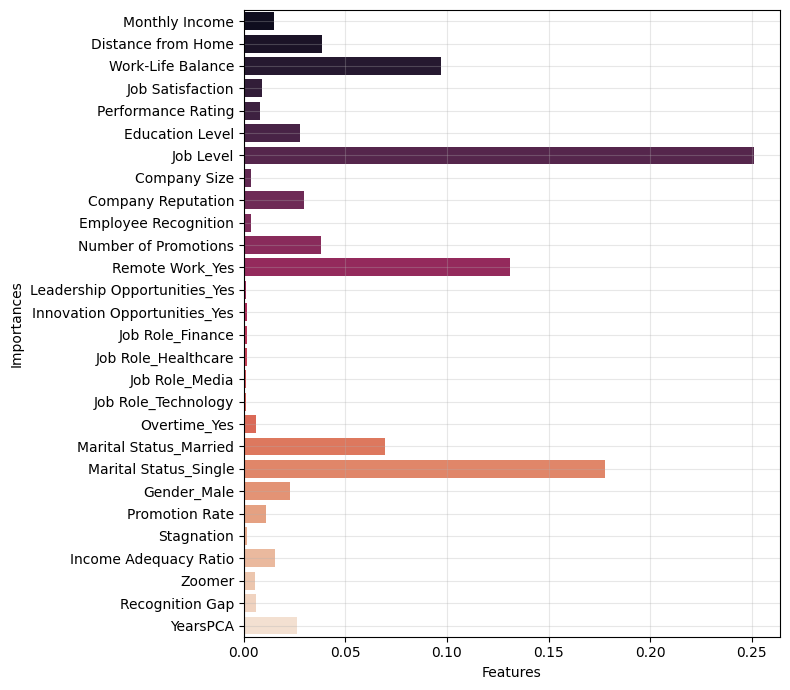

In [ ]:
plt.figure(figsize=(8,7))
feature_importances = best_model.feature_importances_
non_zero_importances = np.where(feature_importances > 1e-03)[0] # by none zero we mean more than 0.001
important_features = X_pca.columns[non_zero_importances]
sns.barplot(y=important_features, x=feature_importances[non_zero_importances], palette='rocket')
plt.grid(alpha=0.3)
plt.xlabel('Features')
plt.ylabel('Importances')
plt.tight_layout()
plt.savefig('Feature importance tunned tree.png', dpi=600)
plt.show()

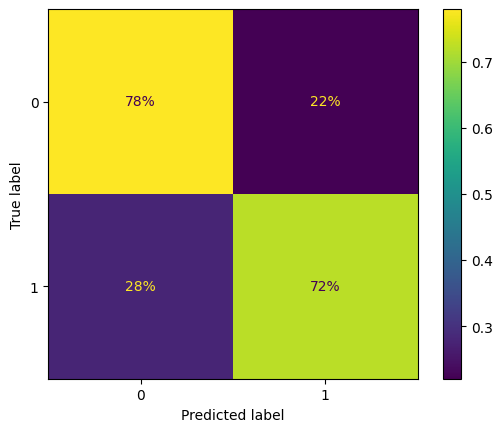

In [ ]:
y_pred_test_proba = best_model.predict_proba(X_test_pca)[:, 1]
ConfusionMatrixDisplay.from_predictions(y_test, [1 if x >= 0.5 else 0 for x in y_pred_test_proba], normalize='true', values_format='.0%')
# plt.title('Confusion matrix for the tunned model')
plt.savefig('Confusion matrix for the tunned model.png', dpi=600)
plt.show()

Now we move forward to the gradient boosting approach. Nevertheless, we will not use simple GradientBoosting since it will cost us a lot of time, but the results will probably be almost identical to the RandomForest above. Hence, we will consider two extensions - XGBoost and CatBoost

The first one will be XGBoost and we will train it on the whole dataset with new features (without PCA)

In [ ]:
! pip install xgboost -q
import xgboost as xgb

In [ ]:
def objective(trial):
  params = {
      'max_depth': trial.suggest_int('max_depth', 2, 20),
      'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
      'n_estimators': trial.suggest_int('n_estimators', 50, 1000, step=50),
      'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0, step=0.1),
      'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.1),
      'objective': 'binary:logistic',
      'random_state': 42,
      'n_jobs': -1,
  }

  model = xgb.XGBClassifier(**params)
  scores = cross_val_score(model, X_new_features, y, cv=3, scoring='recall', n_jobs=-1)

  return scores.mean()

# Create study and optimize
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='XGBoost optimization'
)
n_trials =30
study.optimize(objective, n_trials=n_trials)

print(f"Best trial:")
print(f"Recall: {study.best_value:.4f}")
print(f"Params: {study.best_params}")

# Optimization history
optuna.visualization.plot_optimization_history(study).show()

# Plotting hyperparameter importances
optuna.visualization.plot_param_importances(study).show()

[I 2025-12-18 16:40:39,737] A new study created in memory with name: XGBoost optimization
[I 2025-12-18 16:41:01,437] Trial 0 finished with value: 0.7004728632931047 and parameters: {'max_depth': 9, 'learning_rate': 0.24517932047070642, 'n_estimators': 750, 'min_child_weight': 12, 'colsample_bytree': 0.4, 'subsample': 0.5}. Best is trial 0 with value: 0.7004728632931047.
[I 2025-12-18 16:41:07,814] Trial 1 finished with value: 0.7355494389159434 and parameters: {'max_depth': 3, 'learning_rate': 0.1734451662584154, 'n_estimators': 650, 'min_child_weight': 15, 'colsample_bytree': 0.3, 'subsample': 1.0}. Best is trial 1 with value: 0.7355494389159434.
[I 2025-12-18 16:41:28,460] Trial 2 finished with value: 0.7103888771261203 and parameters: {'max_depth': 17, 'learning_rate': 0.011927270244911253, 'n_estimators': 200, 'min_child_weight': 4, 'colsample_bytree': 0.5, 'subsample': 0.8}. Best is trial 1 with value: 0.7355494389159434.
[I 2025-12-18 16:41:55,270] Trial 3 finished with value: 0

Best trial:
Recall: 0.7402
Params: {'max_depth': 6, 'learning_rate': 0.017754941430735846, 'n_estimators': 750, 'min_child_weight': 6, 'colsample_bytree': 0.7, 'subsample': 0.9}


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X_new_features, y, test_size=0.33, random_state=42)
xgb_model = xgb.XGBClassifier(**study.best_params, early_stopping_rounds=10, eval_metric=["auc", "logloss"], random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=10)

[0]	validation_0-auc:0.79067	validation_0-logloss:0.68747
[10]	validation_0-auc:0.82752	validation_0-logloss:0.65375
[20]	validation_0-auc:0.82809	validation_0-logloss:0.62312
[30]	validation_0-auc:0.82783	validation_0-logloss:0.59944
[40]	validation_0-auc:0.82927	validation_0-logloss:0.58339
[50]	validation_0-auc:0.83070	validation_0-logloss:0.56917
[60]	validation_0-auc:0.83153	validation_0-logloss:0.55668
[70]	validation_0-auc:0.83226	validation_0-logloss:0.54660
[80]	validation_0-auc:0.83328	validation_0-logloss:0.53848
[90]	validation_0-auc:0.83366	validation_0-logloss:0.53076
[100]	validation_0-auc:0.83428	validation_0-logloss:0.52469
[110]	validation_0-auc:0.83521	validation_0-logloss:0.51969
[120]	validation_0-auc:0.83586	validation_0-logloss:0.51541
[130]	validation_0-auc:0.83636	validation_0-logloss:0.51146
[140]	validation_0-auc:0.83744	validation_0-logloss:0.50824
[150]	validation_0-auc:0.83836	validation_0-logloss:0.50535
[160]	validation_0-auc:0.83893	validation_0-logloss

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric=['auc', 'logloss'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.017754941430735846,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=6, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=750, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
print(xgb_model.best_iteration)

515


In [ ]:
params_final = {'max_depth': 6, 'learning_rate': 0.017754941430735846, 'n_estimators': xgb_model.best_iteration+1, 'min_child_weight': 6, 'colsample_bytree': 0.7, 'subsample': 0.9}
xgb_model_final = xgb.XGBClassifier(**params_final, random_state=42)
xgb_model_final.fit(X_new_features, y)
y_train_prediction_xgb = xgb_model_final.predict(X_new_features)
y_test_prediction_xgb = xgb_model_final.predict(X_test_new_features)
print(f'In-sample recall = {recall_score(y, y_train_prediction_xgb)}')
print(f'Out-sample recall {recall_score(y_test, y_test_prediction_xgb)}')
print(f'In-sample accuracy = {accuracy_score(y, y_train_prediction_xgb)}')
print(f'Out-sample accuracy {accuracy_score(y_test, y_test_prediction_xgb)}')

In-sample recall = 0.7614510551203332
Out-sample recall 0.742320819112628
In-sample accuracy = 0.7716198530152019
Out-sample accuracy 0.7556375838926175


What we basically did - we firstly optimized hyperparameters using optuna first. Then we used early stopping (10) to get smaller n_estimators in order to even more prevent overfitting

In [ ]:
cv_scores_xgb_train = cross_validate(xgb_model_final, X_new_features, y, cv=5, scoring=['recall', 'accuracy'], n_jobs=-1)
cv_scores_xgb_test = cross_validate(xgb_model_final, X_test_new_features, y_test, cv=5, scoring=['recall', 'accuracy'], n_jobs=-1)
print(f'XGBM train CV recall: {cv_scores_xgb_train['test_recall'].mean():.3f} (+- {cv_scores_xgb_train['test_recall'].std():.3f})')
print(f'XGBM train CV accuracy: {cv_scores_xgb_train['test_accuracy'].mean():.3f} (+- {cv_scores_xgb_train['test_accuracy'].std():.3f})')
print(f'XGBM test CV recall: {cv_scores_xgb_test['test_recall'].mean():.3f} (+- {cv_scores_xgb_test['test_recall'].std():.3f})')
print(f'XGBM test CV accuracy: {cv_scores_xgb_test['test_accuracy'].mean():.3f} (+- {cv_scores_xgb_test['test_accuracy'].std():.3f})')

XGBM train CV recall: 0.740 (+- 0.005)
XGBM train CV accuracy: 0.752 (+- 0.003)
XGBM test CV recall: 0.732 (+- 0.016)
XGBM test CV accuracy: 0.750 (+- 0.008)


XGBoost performs better than RandomForest in both direct fitting and cross-validation for both metrics

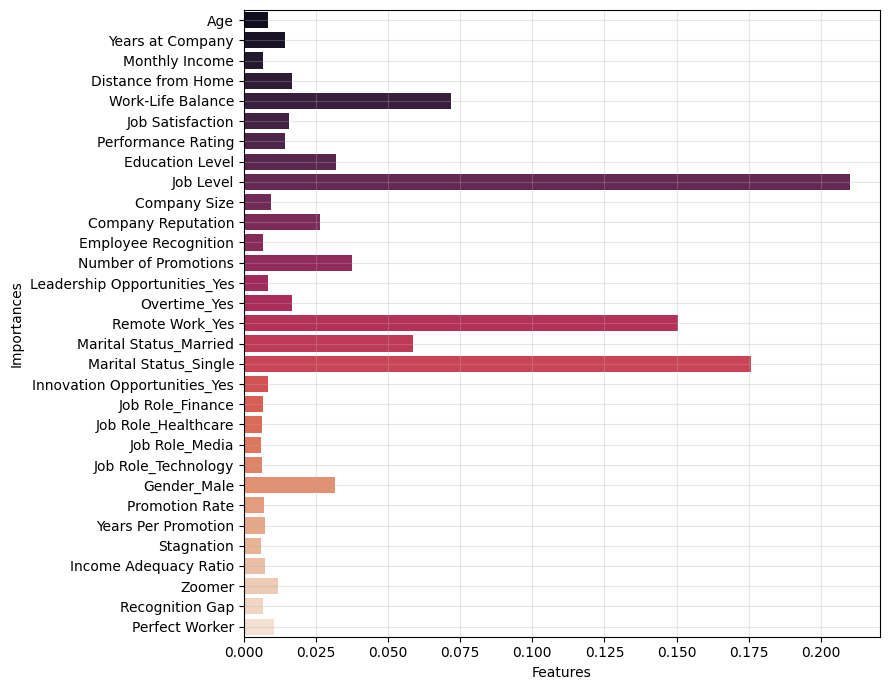

In [ ]:
plt.figure(figsize=(9,7))
feature_importances = xgb_model_final.feature_importances_
non_zero_importances = np.where(feature_importances > 1e-03)[0] # by none zero we mean more than 0.001
important_features = X_new_features.columns[non_zero_importances]
sns.barplot(y=important_features, x=feature_importances[non_zero_importances], palette='rocket')
plt.grid(alpha=0.3)
plt.xlabel('Features')
plt.ylabel('Importances')
plt.tight_layout()
plt.savefig('Feature importance tunned tree.png', dpi=600)
plt.show()

Now we move to catboost. Since it has its own encoders, we will use train_df_catboost which is basically the initial dataset and will add new columns to it.


In [ ]:
train_df_catboost_new = pd.concat([train_df_catboost, new_features_df_train], axis=1)
test_df_catboost_new = pd.concat([test_df_catboost, new_features_df_test], axis=1)
train_df_catboost_new['Number of Promotions'] = train_df_catboost_new['Number of Promotions'].astype('int')
test_df_catboost_new['Number of Promotions'] = test_df_catboost_new['Number of Promotions'].astype('int')
display(train_df_catboost_new.head()), display(test_df_catboost_new.head())

,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Company Reputation,Employee Recognition,Attrition,Promotion Rate,Years Per Promotion,Stagnation,Income Adequacy Ratio,Zoomer,Recognition Gap,Perfect Worker
0,31,Male,19,Education,5390,Excellent,Medium,Average,2,No,...,Excellent,Medium,0,0.105263,6.333333,False,0.736138,False,1.0,False
1,59,Female,4,Media,5534,Poor,High,Low,3,No,...,Fair,Low,0,0.750000,1.000000,False,0.755804,False,0.0,False
2,24,Female,10,Healthcare,8159,Good,High,Low,0,No,...,Poor,Low,0,0.000000,10.000000,True,1.114313,True,0.0,False
3,36,Female,7,Education,3989,Good,High,High,1,No,...,Good,Medium,0,0.142857,3.500000,False,0.544797,False,2.0,False
4,56,Male,41,Education,4821,Fair,Very High,Average,0,Yes,...,Fair,Medium,0,0.000000,41.000000,True,0.656008,False,1.0,False


,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Company Reputation,Employee Recognition,Attrition,Promotion Rate,Years Per Promotion,Stagnation,Income Adequacy Ratio,Zoomer,Recognition Gap,Perfect Worker
0,36,Male,13,Healthcare,8029,Excellent,High,Average,1,Yes,...,Poor,Medium,0,0.076923,6.50,False,1.093273,False,1.0,False
1,35,Male,7,Education,4563,Good,High,Average,1,Yes,...,Good,High,1,0.142857,3.50,False,0.623787,False,0.0,False
2,50,Male,7,Education,5583,Fair,High,Average,3,Yes,...,Good,Low,0,0.428571,1.75,False,0.760368,False,2.0,False
3,58,Male,44,Media,5525,Fair,Very High,High,0,Yes,...,Poor,Low,1,0.000000,44.00,True,0.755297,False,3.0,False
4,39,Male,24,Education,4604,Good,High,Average,0,Yes,...,Good,High,0,0.000000,24.00,True,0.626906,False,0.0,False


(None, None)

In [ ]:
! pip install catboost -q
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.5 MB/s eta 0:00:00


In [ ]:
cat_features = list(train_df_catboost_new.select_dtypes(include='object').columns)
X_cat = train_df_catboost_new.drop(columns=['Attrition'])
y_cat = train_df_catboost_new['Attrition']
X_train, X_valid, y_train, y_valid = train_test_split(X_cat, y_cat, test_size = 0.33, random_state = 42)

# Trying just out of the box model
model = CatBoostClassifier(
    eval_metric='Logloss',
    random_seed=42,
    verbose=50
)
model.fit(
    X_train, y_train,
    cat_features = cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
    # logging_level='Verbose',
)

Learning rate set to 0.078783
0:	learn: 0.6660726	test: 0.6659721	best: 0.6659721 (0)	total: 112ms	remaining: 1m 51s
50:	learn: 0.4834826	test: 0.4857488	best: 0.4857488 (50)	total: 5.33s	remaining: 1m 39s
100:	learn: 0.4732383	test: 0.4793114	best: 0.4793114 (100)	total: 9.92s	remaining: 1m 28s
150:	learn: 0.4671153	test: 0.4776840	best: 0.4776840 (150)	total: 14.5s	remaining: 1m 21s
200:	learn: 0.4615631	test: 0.4773439	best: 0.4772571 (194)	total: 20.5s	remaining: 1m 21s
250:	learn: 0.4565051	test: 0.4775176	best: 0.4772571 (194)	total: 25.4s	remaining: 1m 15s
300:	learn: 0.4513369	test: 0.4778719	best: 0.4772571 (194)	total: 31.5s	remaining: 1m 13s
350:	learn: 0.4466500	test: 0.4782777	best: 0.4772571 (194)	total: 36.5s	remaining: 1m 7s
400:	learn: 0.4420388	test: 0.4788783	best: 0.4772571 (194)	total: 42s	remaining: 1m 2s
450:	learn: 0.4379154	test: 0.4792789	best: 0.4772571 (194)	total: 47.8s	remaining: 58.2s
500:	learn: 0.4337423	test: 0.4796038	best: 0.4772571 (194)	total: 52.9

In [ ]:
X_cat_test = test_df_catboost_new.drop(columns=['Attrition'])
catboost = CatBoostClassifier(iterations=195, random_seed=42, verbose=50).fit(X_cat, y, cat_features=cat_features)
y_train_prediction_cat = catboost.predict(X_cat)
y_test_prediction_cat = catboost.predict(X_cat_test)
print()
print(f'In-sample recall = {recall_score(y, y_train_prediction_cat)}')
print(f'Out-sample recall {recall_score(y_test, y_test_prediction_cat)}')
print(f'In-sample accuracy = {accuracy_score(y, y_train_prediction_cat)}')
print(f'Out-sample accuracy {accuracy_score(y_test, y_test_prediction_cat)}')

Learning rate set to 0.264239
0:	learn: 0.6453565	total: 98.6ms	remaining: 19.1s
50:	learn: 0.4691314	total: 3.15s	remaining: 8.89s
100:	learn: 0.4575712	total: 6.14s	remaining: 5.71s
150:	learn: 0.4471254	total: 10.6s	remaining: 3.08s
194:	learn: 0.4387887	total: 13.2s	remaining: 0us

In-sample recall = 0.7644505610840567
Out-sample recall 0.7411831626848692
In-sample accuracy = 0.7769891607100909
Out-sample accuracy 0.7532214765100671


In [ ]:
# Manual implementation of cross-validation for catbost
from sklearn.model_selection import StratifiedKFold
def manual_catboost_cv(X, y, cat_features, n_splits=5):
  kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

  recall_scores = []
  accuracy_scores = []

  for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
      X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
      y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

      model = catboost
      model.fit(
          X_train, y_train,
          cat_features=cat_features,
          eval_set=(X_val, y_val),
          use_best_model=True,
          verbose=False
      )
      y_pred = model.predict(X_val)

      recall = recall_score(y_val, y_pred)
      accuracy = accuracy_score(y_val, y_pred)

      recall_scores.append(recall)
      accuracy_scores.append(accuracy)

      print(f"Fold {fold+1}: Recall = {recall:.4f}, Accuracy = {accuracy:.4f}")

  print(f"Mean Recall: {np.mean(recall_scores):.4f} (+- {np.std(recall_scores):.4f})")
  print(f"Mean Accuracy: {np.mean(accuracy_scores):.4f} (+- {np.std(accuracy_scores):.4f})")

  return {
        'recall': recall_scores,
        'accuracy': accuracy_scores,
        'mean_recall': np.mean(recall_scores),
        'mean_accuracy': np.mean(accuracy_scores)
    }
results = manual_catboost_cv(X_cat, y, cat_features, n_splits=5)

Fold 1: Recall = 0.7472, Accuracy = 0.7595
Fold 2: Recall = 0.7324, Accuracy = 0.7474
Fold 3: Recall = 0.7341, Accuracy = 0.7468
Fold 4: Recall = 0.7507, Accuracy = 0.7554
Fold 5: Recall = 0.7463, Accuracy = 0.7574
Mean Recall: 0.7421 (+- 0.0074)
Mean Accuracy: 0.7533 (+- 0.0052)


In [ ]:
results_test = manual_catboost_cv(X_cat_test, y_test, cat_features, n_splits=5)

Fold 1: Recall = 0.7425, Accuracy = 0.7570
Fold 2: Recall = 0.7091, Accuracy = 0.7581
Fold 3: Recall = 0.7283, Accuracy = 0.7550
Fold 4: Recall = 0.7377, Accuracy = 0.7477
Fold 5: Recall = 0.7448, Accuracy = 0.7513
Mean Recall: 0.7325 (+- 0.0130)
Mean Accuracy: 0.7538 (+- 0.0038)


Out of the box catboost is better than XGBM and RandomForest and so we will stop on that.

The last thing to do is actually to use voting rule in order to combine the power of linear estimator (logistic regression), non-linear estimator (decision tree with best splitting) and ensembles. As for ensembles, we will use three votings, with RandomForest, XGBoost and CatBoost. However, since for different models we used different dataset, we will consider manual implementation.

In [ ]:
logreg = best_estimator_log_reg.fit(X_pca, y)
decision_tree = best_tree.fit(X_pca, y)
random_forest = random_forest_trees.fit(X_pca, y)
xgbm = xgb_model_final.fit(X_new_features, y)
catboost = catboost.fit(X_cat, y, cat_features=cat_features)

In [ ]:
prediction_logreg = logreg.predict_proba(X_test_pca)[:,1]
prediction_decision_tree = decision_tree.predict_proba(X_test_pca)[:,1]
prediction_random_forest = random_forest.predict_proba(X_test_pca)[:,1]
prediction_xgbm = xgbm.predict_proba(X_test_new_features)[:,1]
prediction_catboost = catboost.predict_proba(X_cat_test)[:,1]

df_0 = pd.DataFrame(columns = ['Logreg', 'Decision Tree', 'Random forest'], data=np.vstack((prediction_logreg, prediction_decision_tree, prediction_random_forest)).T)
voting_prediction_0 = df_0.median(axis=1).apply(lambda x: 1 if x >= 0.5 else 0).to_list()

df_1 = pd.DataFrame(columns = ['Logreg', 'Decision Tree', 'XGBoost'], data=np.vstack((prediction_logreg, prediction_decision_tree, prediction_xgbm)).T)
voting_prediction_1 = df_1.median(axis=1).apply(lambda x: 1 if x >= 0.5 else 0).to_list()

df_2 = pd.DataFrame(columns = ['Logreg', 'Decision Tree', 'CatBoost'], data=np.vstack((prediction_logreg, prediction_decision_tree, prediction_catboost)).T)
voting_prediction_2 = df_2.median(axis=1).apply(lambda x: 1 if x >= 0.5 else 0).to_list()


In [ ]:
print(f'Out-of-sample recall for voting 0 = {recall_score(y_test, voting_prediction_0)}')
print(f'Out-of-sample recall for voting 1 = {recall_score(y_test, voting_prediction_1)}')
print(f'Out-of-sample recall for voting 2 = {recall_score(y_test, voting_prediction_2)}')

Out-of-sample recall for voting 0 = 0.7329351535836177
Out-of-sample recall for voting 1 = 0.7356370875995449
Out-of-sample recall for voting 2 = 0.735494880546075


In [ ]:
print(f'Out-of-sample accuracy for voting 0 = {accuracy_score(y_test, voting_prediction_0)}')
print(f'Out-of-sample accuracy for voting 1 = {accuracy_score(y_test, voting_prediction_1)}')
print(f'Out-of-sample accuracy for voting 2 = {accuracy_score(y_test, voting_prediction_2)}')

Out-of-sample accuracy for voting 0 = 0.7473825503355704
Out-of-sample accuracy for voting 1 = 0.7491946308724832
Out-of-sample accuracy for voting 2 = 0.7487919463087248
